# **Phase B — Correlation Analysis & Feature Selection**

This notebook covers the full Phase B pipeline:

| Section | Description |
|---------|-------------|
| 1 | **Pearson / Spearman Correlations** with Life Expectancy, by dataset |
| 2 | **Pearson vs Spearman comparison** — non-linearity detection |
| 3 | **Feature-to-feature heatmap** + multicollinearity pair detection |
| 4 | **Within-country temporal correlations** + cross-sectional vs within comparison |
| 5 | **Vaccination–Mortality pathways** |
| 6 | **Health Spending Efficiency** + Preston Curve |
| 7 | **VIF Analysis** *(new)* — Variance Inflation Factor for all candidates |
| 8 | **Partial Correlation / Confounding Checks** *(new)* — controlling for GDP |
| 9 | **Lag Correlation Analysis** *(new)* — 1-year and 3-year lags |
| 10 | **Preliminary Random Forest Importance** *(new)* — cross-validates correlation ranking |
| 11 | **Candidate Selection** — 8-phase pipeline → `candidates_correlations.json` |

---
### ⚠️ Note on `framework_b_clustering.ipynb`
The clustering notebook is **Phase D work run early** — it benchmarks countries and generates policy diagnostics that should be grounded in the trained ML model's SHAP-derived feature importance. It is methodologically valid but should be re-validated after Phase C. The `candidates_correlations.json` it currently uses will be superseded by model-validated feature rankings from Phase C.

## **~Libraries~**

In [1]:
import glob
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import json as _json

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from collections import defaultdict

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression

import importlib
import functions as fns
importlib.reload(fns)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

## **~Load Data~**

In [2]:
df = pd.read_csv('Phase_A_docs/df_merged_all_imputed.csv')

In [3]:
# Rebuild dict_data_agg from the imputed merged dataframe
# ============================================================================

# Define which columns belong to which dataset
dataset_mapping = {
    'life_expectancy': ['Life Expectancy'],
    'child-mortality': ['Child mortality rate'],
    'average-years-of-schooling-among-adults': ['Average years of schooling'],
    'death_rate_from_suicides_gho': ['Suicide Rate'],
    'homicide_rate_unodc': ['Homicide Rate'],
    'gdp_per_capita_penn_world_table': ['GDP per Capita'],
    'public_healthcare_spending_share_gdp': ['% GDP on Health Expenditure'],
    'education_spending_share_gdp': ['% GDP on Education Expenditure'],
    'population': ['Population'],
    'global_vaccination_coverage': [
        'BCG', 'DTP1', 'DTP3', 'HepB3', 'Hib3', 'MCV1', 'MCV2',
        'PCV3', 'Pol3', 'RCV1', 'RotaC'
    ],
    'annual_number_of_deaths_by_cause': [
        'Acute hepatitis', 'Alcohol use disorders',
        "Alzheimer's disease and other dementias", 'Cardiovascular diseases',
        'Chronic kidney disease', 'Chronic respiratory diseases',
        'Cirrhosis and other chronic liver diseases', 'Conflict and terrorism',
        'Diabetes mellitus', 'Diarrheal diseases', 'Digestive diseases',
        'Drowning', 'Drug use disorders', 'Environmental heat and cold exposure',
        'Exposure to forces of nature', 'Fire, heat, and hot substances',
        'HIV/AIDS', 'Interpersonal violence', 'Lower respiratory infections',
        'Malaria', 'Maternal disorders', 'Meningitis', 'Neonatal disorders',
        'Neoplasms', 'Nutritional deficiencies', "Parkinson's disease",
        'Poisonings', 'Protein-energy malnutrition', 'Road injuries',
        'Self-harm', 'Tuberculosis'
    ],
    'poverty_explorer': [
        'Share below $2.15 a day', 'Share below $3.65 a day',
        'Share below $6.85 a day', 'Share below $20 a day',
        'Share below $40 a day', 'Mean income or consumption per day',
        'Median income or consumption per day', 'gini', 'palma_ratio',
        'p90_p10_ratio', 'bottom50_share', 'decile1_share', 'decile10_share'
    ],
}

base_cols = ['Country', 'Year', 'Continent']
dict_data_agg = {}

for key, value_cols in dataset_mapping.items():
    existing_cols = [c for c in value_cols if c in df.columns]
    if existing_cols:
        dict_data_agg[key] = df[base_cols + existing_cols].copy()

print(f'Datasets loaded: {list(dict_data_agg.keys())}')
print(f'Panel shape: {df.shape}  |  Countries: {df["Country"].nunique()}  |  Years: {df["Year"].min()}–{df["Year"].max()}')

Datasets loaded: ['life_expectancy', 'child-mortality', 'average-years-of-schooling-among-adults', 'death_rate_from_suicides_gho', 'homicide_rate_unodc', 'gdp_per_capita_penn_world_table', 'public_healthcare_spending_share_gdp', 'education_spending_share_gdp', 'population', 'global_vaccination_coverage', 'annual_number_of_deaths_by_cause', 'poverty_explorer']
Panel shape: (3096, 67)  |  Countries: 129  |  Years: 2000–2023


In [4]:
# ── Log-transform skewed features in dict_data_agg BEFORE correlation analysis
# ============================================================================
# Based on Phase A supplement recommendations (|skew| > 1).
# We transform IN PLACE on a copy so the original data is not modified.
# Only numeric columns matching the log list are affected.
# ============================================================================

LOG_TRANSFORM_COLS = [
    # Economic
    'GDP per Capita', 'Population',
    # Social
    'Homicide Rate', 'Suicide Rate',
    # Child health
    'Child mortality rate', 'Child Mortality Rate',
    # Poverty
    'Share below $2.15 a day', 'Share below $3.65 a day',
    'Share below $6.85 a day', 'Share below $20 a day',
    'Mean income or consumption per day', 'Median income or consumption per day',
    'palma_ratio', 'p90_p10_ratio',
    # Causes of death (all heavily right-skewed)
    'HIV/AIDS', 'Malaria', 'Tuberculosis', 'Diarrheal diseases',
    'Neonatal disorders', 'Maternal disorders', 'Lower respiratory infections',
    'Cardiovascular diseases', 'Neoplasms', 'Diabetes mellitus',
    'Chronic respiratory diseases', 'Conflict and terrorism',
    'Drug use disorders', 'Exposure to forces of nature',
    'Acute hepatitis', 'Alcohol use disorders',
    "Alzheimer's disease and other dementias", 'Chronic kidney disease',
    'Cirrhosis and other chronic liver diseases', 'Digestive diseases',
    'Drowning', 'Environmental heat and cold exposure',
    'Fire, heat, and hot substances', 'Interpersonal violence',
    'Meningitis', 'Nutritional deficiencies', "Parkinson's disease",
    'Poisonings', 'Protein-energy malnutrition', 'Road injuries',
    'Self-harm',
]

dict_data_log = {}
transformed_report = []

for dataset_key, df in dict_data_agg.items():
    df_log = df.copy()
    for col in LOG_TRANSFORM_COLS:
        if col in df_log.columns:
            df_log[col] = np.log1p(df_log[col].clip(lower=0))
            transformed_report.append({'dataset': dataset_key, 'column': col})
    dict_data_log[dataset_key] = df_log

print(f"✅ Log-transformed {len(transformed_report)} columns across {len(dict_data_log)} datasets")
print("Transformed columns:")
for r in transformed_report:
    print(f"  [{r['dataset']}] {r['column']}")

✅ Log-transformed 44 columns across 12 datasets
Transformed columns:
  [child-mortality] Child mortality rate
  [death_rate_from_suicides_gho] Suicide Rate
  [homicide_rate_unodc] Homicide Rate
  [gdp_per_capita_penn_world_table] GDP per Capita
  [population] Population
  [annual_number_of_deaths_by_cause] HIV/AIDS
  [annual_number_of_deaths_by_cause] Malaria
  [annual_number_of_deaths_by_cause] Tuberculosis
  [annual_number_of_deaths_by_cause] Diarrheal diseases
  [annual_number_of_deaths_by_cause] Neonatal disorders
  [annual_number_of_deaths_by_cause] Maternal disorders
  [annual_number_of_deaths_by_cause] Lower respiratory infections
  [annual_number_of_deaths_by_cause] Cardiovascular diseases
  [annual_number_of_deaths_by_cause] Neoplasms
  [annual_number_of_deaths_by_cause] Diabetes mellitus
  [annual_number_of_deaths_by_cause] Chronic respiratory diseases
  [annual_number_of_deaths_by_cause] Conflict and terrorism
  [annual_number_of_deaths_by_cause] Drug use disorders
  [annual

---
# **1. Pearson / Spearman Correlations with Life Expectancy**

In [5]:
# Correlations based on Life Expectancy
# ============================================================================

# Pearson Correlation
results_pearson = fns.correlate_life_expectancy_by_dataset(
    dict_data_log,
    life_exp_key='life_expectancy',
    method='pearson'
)

# Spearman Correlation
results_spearman = fns.correlate_life_expectancy_by_dataset(
    dict_data_log,
    life_exp_key='life_expectancy',
    method='spearman'
)

Correlations: Life Expectancy vs All Datasets

Dataset base: life_expectancy
Columns: Life Expectancy
Method: pearson
Shape: (3096, 4)

────────────────────────────────────────────────────────────────────────────────
📊 CHILD-MORTALITY
────────────────────────────────────────────────────────────────────────────────
Len after merged: 3,096
Numeric Variables: 1

🔵 Correlations: 1

  🔴 -0.932  (3,096 obs)  |  Child mortality rate

────────────────────────────────────────────────────────────────────────────────
📊 AVERAGE-YEARS-OF-SCHOOLING-AMONG-ADULTS
────────────────────────────────────────────────────────────────────────────────
Len after merged: 3,096
Numeric Variables: 1

🔵 Correlations: 1

  🔵 +0.708  (3,096 obs)  |  Average years of schooling

────────────────────────────────────────────────────────────────────────────────
📊 DEATH_RATE_FROM_SUICIDES_GHO
────────────────────────────────────────────────────────────────────────────────
Len after merged: 3,096
Numeric Variables: 1

🔵 Cor

In [36]:
#plot_correlations_pearson = fns.plot_all_correlations_summary(results_pearson, top_n=10)
#plot_correlations_pearson

#plot_correlations_spearman = fns.plot_all_correlations_summary(results_spearman, top_n=10)
#plot_correlations_spearman

---
# **2. Pearson vs Spearman Comparison — Non-Linearity Detection**

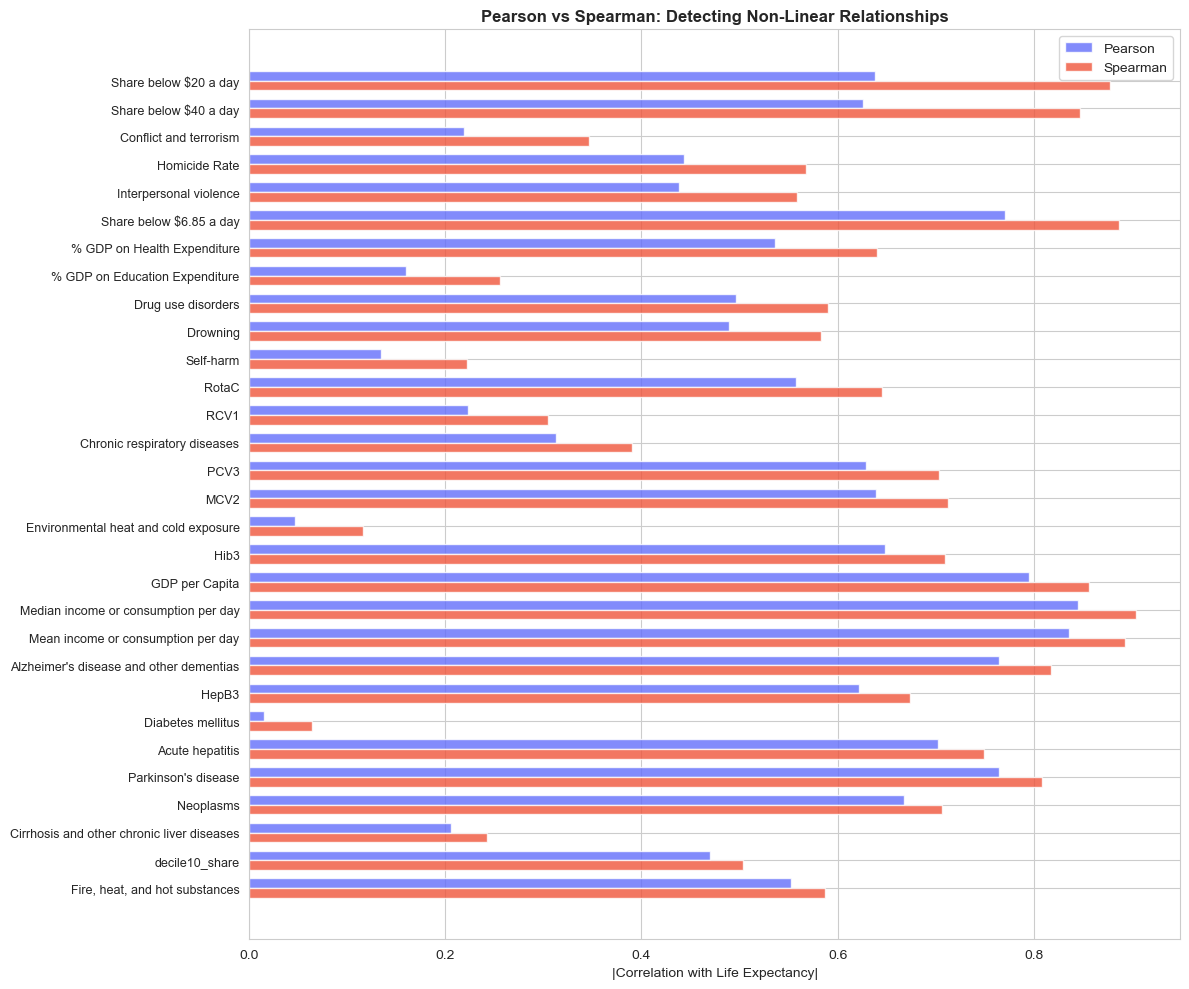


📊 Variables with strongest non-linearity (|Spearman| - |Pearson| > 0.05):
                               Variable  Pearson  Spearman  Abs_Diff
                  Share below $20 a day   -0.638    -0.878     0.240
                  Share below $40 a day   -0.626    -0.847     0.221
                 Conflict and terrorism   -0.219    -0.346     0.127
                          Homicide Rate   -0.443    -0.568     0.125
                 Interpersonal violence   -0.438    -0.559     0.121
                Share below $6.85 a day   -0.771    -0.887     0.116
            % GDP on Health Expenditure    0.536     0.640     0.104
         % GDP on Education Expenditure    0.160     0.256     0.096
                     Drug use disorders    0.496     0.590     0.093
                               Drowning   -0.489    -0.583     0.093
                              Self-harm    0.134     0.222     0.088
                                  RotaC    0.558     0.645     0.087
                            

In [8]:
# PEARSON vs SPEARMAN COMPARISON
# ============================================================================

def build_pearson_vs_spearman_comparison(results_pearson, results_spearman):
    rows = []
    for dataset_key, vars_dict_p in results_pearson.items():
        vars_dict_s = results_spearman.get(dataset_key)
        if vars_dict_s is None:
            continue
        for var_name, stats_p in vars_dict_p.items():
            stats_s = vars_dict_s.get(var_name)
            if stats_s is None:
                continue
            pearson_r  = float(stats_p['correlation'])
            spearman_r = float(stats_s['correlation'])
            diff = abs(spearman_r) - abs(pearson_r)
            rows.append({
                'Dataset': dataset_key,
                'Variable': var_name,
                'Pearson': round(pearson_r, 3),
                'Spearman': round(spearman_r, 3),
                'Abs_Diff': round(diff, 3),
                'Non_Linear_Flag': '⚠️' if abs(diff) > 0.05 else ''
            })
    return pd.DataFrame(rows).sort_values('Abs_Diff', ascending=False)


def plot_pearson_vs_spearman(results_pearson, results_spearman, backend='plotly'):
    df_comparison = build_pearson_vs_spearman_comparison(results_pearson, results_spearman)
    top_vars = df_comparison.nlargest(30, 'Abs_Diff') if len(df_comparison) > 30 else df_comparison

    if backend == 'plotly':
        fig = go.Figure()
        fig.add_trace(go.Bar(
            y=top_vars['Variable'], x=top_vars['Pearson'].abs(),
            name='|Pearson|', orientation='h', marker_color='#636EFA'
        ))
        fig.add_trace(go.Bar(
            y=top_vars['Variable'], x=top_vars['Spearman'].abs(),
            name='|Spearman|', orientation='h', marker_color='#EF553B'
        ))
        fig.update_layout(
            title='Pearson vs Spearman: Detecting Non-Linear Relationships<br>'
                  '<sub>Large gaps between bars indicate non-linear associations with Life Expectancy</sub>',
            xaxis_title='|Correlation with Life Expectancy|',
            yaxis=dict(autorange='reversed'),
            barmode='group',
            height=700, width=900,
            template='plotly_white',
            legend=dict(x=0.7, y=0.02)
        )
        fig.show()
    else:
        fig, ax = plt.subplots(figsize=(12, 10))
        y_pos = np.arange(len(top_vars))
        bar_height = 0.35
        ax.barh(y_pos - bar_height/2, top_vars['Pearson'].abs().values,
                bar_height, label='Pearson', color='#636EFA', alpha=0.8)
        ax.barh(y_pos + bar_height/2, top_vars['Spearman'].abs().values,
                bar_height, label='Spearman', color='#EF553B', alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_vars['Variable'].values, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('|Correlation with Life Expectancy|')
        ax.set_title('Pearson vs Spearman: Detecting Non-Linear Relationships', fontweight='bold')
        ax.legend()
        plt.tight_layout()
        plt.show()

    print("\n📊 Variables with strongest non-linearity (|Spearman| - |Pearson| > 0.05):")
    flagged = df_comparison[df_comparison['Abs_Diff'] > 0.05][['Variable', 'Pearson', 'Spearman', 'Abs_Diff']]
    print(flagged.to_string(index=False))
    return df_comparison


df_comparison = plot_pearson_vs_spearman(results_pearson, results_spearman, backend='matplotlib')

---
# **3. Feature-to-Feature Heatmap & Multicollinearity Pairs**

In [9]:
# MERGE ALL DATASETS INTO A SINGLE PANEL
# ============================================================================

def merge_all_datasets(dict_data, base_key='life_expectancy', exclude_keys=None):
    if exclude_keys is None:
        exclude_keys = ['population']

    df_panel = dict_data[base_key][['Country', 'Year', 'Life Expectancy', 'Continent']].copy()

    for key, df_ds in dict_data.items():
        if key == base_key or key in exclude_keys:
            continue
        cols_to_use = ['Country', 'Year'] + [
            c for c in df_ds.columns if c not in ['Country', 'Year', 'Continent']
        ]
        df_merge = df_ds[cols_to_use].copy()
        rename_map = {c: f"{key}__{c}" for c in df_merge.columns if c not in ['Country', 'Year']}
        df_merge = df_merge.rename(columns=rename_map)
        df_panel = df_panel.merge(df_merge, on=['Country', 'Year'], how='left')

    print(f"✅ Merged panel shape: {df_panel.shape}")
    print(f"   Countries: {df_panel['Country'].nunique()}  |  Years: {df_panel['Year'].min()}–{df_panel['Year'].max()}")
    return df_panel


df_panel = merge_all_datasets(dict_data_log)
df_panel_raw = merge_all_datasets(dict_data_agg)

✅ Merged panel shape: (3096, 66)
   Countries: 129  |  Years: 2000–2023
✅ Merged panel shape: (3096, 66)
   Countries: 129  |  Years: 2000–2023


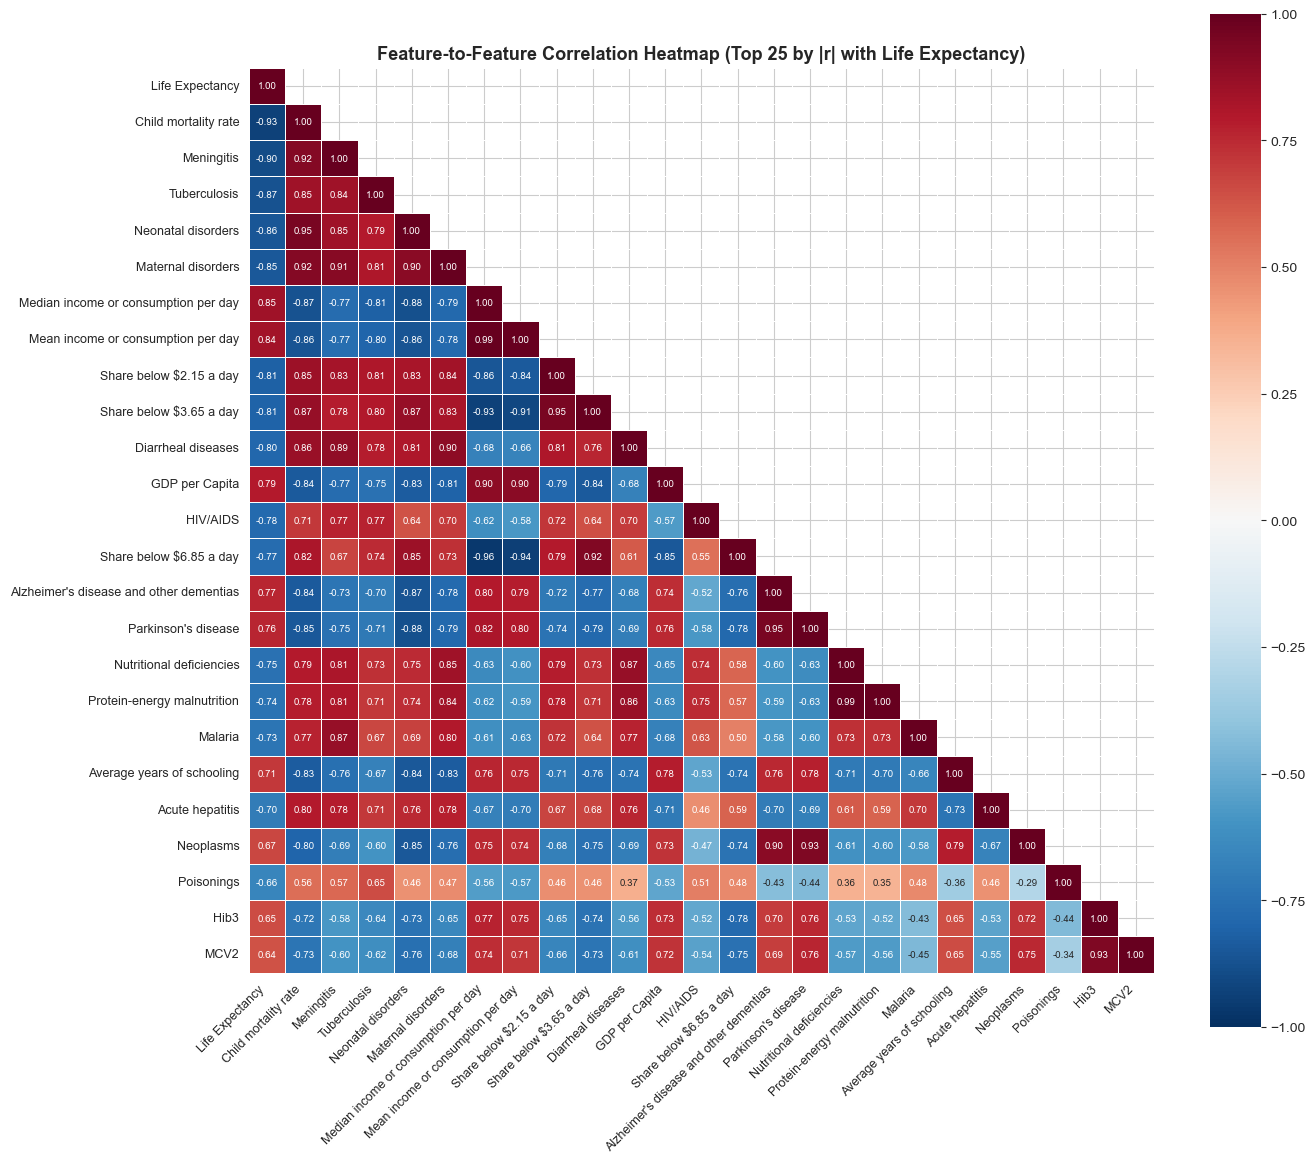

In [10]:
# FEATURE-TO-FEATURE CORRELATION HEATMAP
# ============================================================================

def plot_feature_correlation_heatmap(df_panel, max_features=25, backend='plotly'):
    numeric_cols = df_panel.select_dtypes(include=[np.number]).columns.tolist()
    if 'Year' in numeric_cols:
        numeric_cols.remove('Year')

    le_col = [c for c in numeric_cols if 'Life Expectancy' in c or 'life_expectancy' in c.lower()]
    if not le_col:
        print("⚠️ Life Expectancy column not found")
        return None, None

    le_name = le_col[0]
    corr_with_le = df_panel[numeric_cols].corrwith(df_panel[le_name]).abs().sort_values(ascending=False)
    top_features = corr_with_le.head(max_features).index.tolist()
    corr_matrix  = df_panel[top_features].corr()
    clean_names  = [c.split('__')[-1] if '__' in c else c for c in top_features]
    title = f'Feature-to-Feature Correlation Heatmap (Top {len(top_features)} by |r| with Life Expectancy)'

    if backend == 'plotly':
        fig = px.imshow(
            corr_matrix.values, x=clean_names, y=clean_names,
            color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
            text_auto='.2f', title=title, aspect='auto'
        )
        fig.update_layout(height=800, width=900, template='plotly_white',
                          xaxis=dict(tickangle=45, tickfont=dict(size=9)),
                          yaxis=dict(tickfont=dict(size=9)))
        fig.show()
    else:
        fig, ax = plt.subplots(figsize=(14, 12))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
        sns.heatmap(corr_matrix, mask=mask, xticklabels=clean_names, yticklabels=clean_names,
                    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
                    annot=True, fmt='.2f', annot_kws={'size': 7},
                    square=True, linewidths=0.5, ax=ax)
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.set_xticklabels(clean_names, rotation=45, ha='right', fontsize=9)
        ax.set_yticklabels(clean_names, rotation=0, fontsize=9)
        plt.tight_layout()
        plt.show()

    return corr_matrix, top_features


corr_matrix, top_features = plot_feature_correlation_heatmap(df_panel, max_features=25, backend='matplotlib')

In [11]:
def find_high_correlations(corr_matrix, threshold=0.8):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append({
                    'Feature_1': cols[i].split('__')[-1],
                    'Feature_2': cols[j].split('__')[-1],
                    'Correlation': round(r, 3)
                })
    df_pairs = pd.DataFrame(pairs).sort_values('Correlation', key=abs, ascending=False)

    neighbors = defaultdict(set)
    for _, row in df_pairs.iterrows():
        neighbors[row['Feature_1']].add(row['Feature_2'])
        neighbors[row['Feature_2']].add(row['Feature_1'])

    visited = set()
    clusters = {}
    cluster_id = 0
    for feature in neighbors:
        if feature not in visited:
            queue = [feature]
            visited.add(feature)
            members = []
            while queue:
                node = queue.pop(0)
                members.append(node)
                for neighbor in neighbors[node]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)
            for m in members:
                clusters[m] = f"Cluster {cluster_id}"
            cluster_id += 1

    df_pairs['Cluster'] = df_pairs['Feature_1'].map(clusters)
    return df_pairs


numeric_cols = [c for c in df_panel.select_dtypes(include=[np.number]).columns if c != 'Year']
full_corr    = df_panel[numeric_cols].corr()
df_high_corr = find_high_correlations(full_corr, threshold=0.8)

print(f"📊 Feature pairs with |r| ≥ 0.8 ({len(df_high_corr)} pairs):")
print(df_high_corr.to_string(index=False))

print(f"\n📊 Multicollinearity Clusters:")
cluster_members  = df_high_corr[['Feature_1', 'Cluster']].rename(columns={'Feature_1': 'Feature'})
cluster_members2 = df_high_corr[['Feature_2', 'Cluster']].rename(columns={'Feature_2': 'Feature'})
all_members = pd.concat([cluster_members, cluster_members2]).drop_duplicates()
for cluster, group in all_members.groupby('Cluster'):
    features = sorted(group['Feature'].unique())
    print(f"  {cluster}: {', '.join(features)}")

📊 Feature pairs with |r| ≥ 0.8 (117 pairs):
                                 Feature_1                               Feature_2  Correlation   Cluster
                                      gini                          bottom50_share       -0.995 Cluster 0
                  Nutritional deficiencies             Protein-energy malnutrition        0.994 Cluster 1
        Mean income or consumption per day    Median income or consumption per day        0.993 Cluster 1
                                      gini                             palma_ratio        0.992 Cluster 0
                     Share below $20 a day                   Share below $40 a day        0.986 Cluster 1
                               palma_ratio                          decile10_share        0.983 Cluster 0
                               palma_ratio                          bottom50_share       -0.982 Cluster 0
                                      gini                          decile10_share        0.980 Cluster 0
  

---
# **4. Within-Country Temporal Correlations & Cross-Sectional Comparison**

In [12]:
TARGET = 'Life Expectancy'


In [13]:
# WITHIN-COUNTRY TEMPORAL CORRELATIONS
# ============================================================================

def compute_within_country_correlations(df_panel, target=TARGET, min_years=10):
    numeric_cols = df_panel.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in ['Year'] and c != target]
    countries    = df_panel['Country'].unique()
    within_results = []

    for country in countries:
        df_c = df_panel[df_panel['Country'] == country].sort_values('Year')
        for var in feature_cols:
            pair = df_c[[target, var]].dropna()
            if len(pair) < min_years:
                continue
            r, p = stats.pearsonr(pair[target], pair[var])
            within_results.append({'Country': country, 'Variable': var,
                                   'Correlation': r, 'P_Value': p, 'N_Years': len(pair)})

    df_within = pd.DataFrame(within_results)
    within_avg = (
        df_within.groupby('Variable')
        .agg(
            Mean_Within_r=('Correlation', 'mean'),
            Median_Within_r=('Correlation', 'median'),
            Std_Within_r=('Correlation', 'std'),
            N_Countries=('Country', 'nunique'),
            Pct_Significant=('P_Value', lambda x: (x < 0.05).mean() * 100)
        )
        .sort_values('Mean_Within_r', key=abs, ascending=False)
    )
    print(f"✅ Within-country correlations: {len(df_within):,} country-variable pairs")
    print("\n📊 Top 20 variables by average within-country correlation:")
    print(within_avg.head(20).round(3).to_string())
    return df_within, within_avg


df_within, within_avg = compute_within_country_correlations(df_panel)

✅ Within-country correlations: 7,980 country-variable pairs

📊 Top 20 variables by average within-country correlation:
                                                                           Mean_Within_r  Median_Within_r  Std_Within_r  N_Countries  Pct_Significant
Variable                                                                                                                                             
child-mortality__Child mortality rate                                             -0.864           -0.943         0.224          129           96.124
annual_number_of_deaths_by_cause__Meningitis                                      -0.800           -0.883         0.223          129           93.798
annual_number_of_deaths_by_cause__Neonatal disorders                              -0.789           -0.852         0.217          129           93.023
average-years-of-schooling-among-adults__Average years of schooling                0.786            0.894         0.253          12

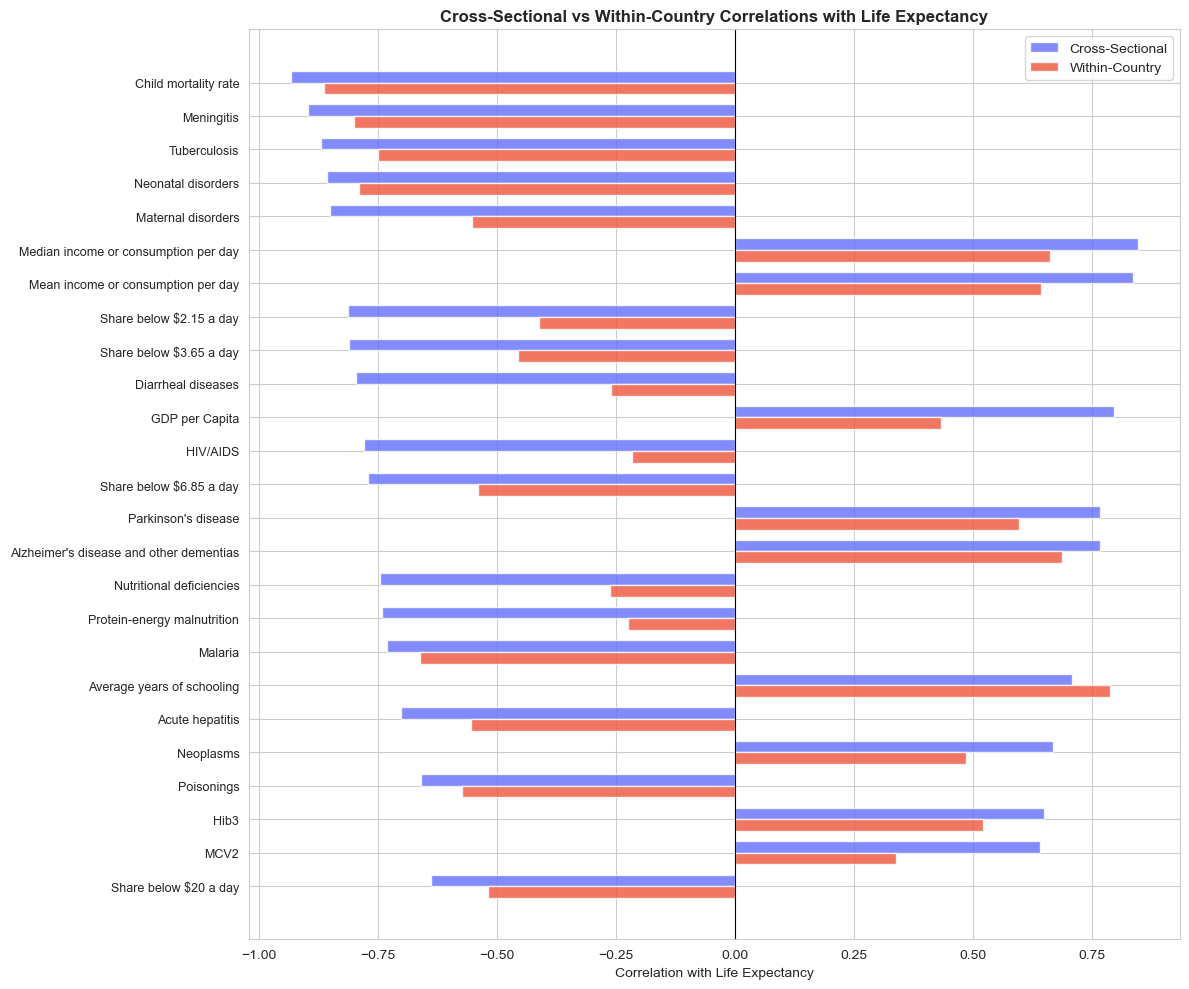

In [14]:
# CROSS-SECTIONAL vs WITHIN-COUNTRY COMPARISON
# ============================================================================

def compare_cross_vs_within(df_panel, within_avg, target=TARGET):
    numeric_cols = df_panel.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in ['Year'] and c != target]
    comparison   = []

    for var in feature_cols:
        pair = df_panel[[target, var]].dropna()
        if len(pair) < 30:
            continue
        cross_r = pair[target].corr(pair[var])
        if var not in within_avg.index:
            continue
        within_r   = within_avg.loc[var, 'Mean_Within_r']
        clean_name = var.split('__')[-1] if '__' in var else var
        comparison.append({
            'Variable':          clean_name,
            'Full_Name':         var,
            'Cross_Sectional_r': round(cross_r, 3),
            'Within_Country_r':  round(within_r, 3),
            'Both_Strong':       '✅' if abs(cross_r) > 0.3 and abs(within_r) > 0.3 else '',
            'Cross_Only':        '⚠️' if abs(cross_r) > 0.3 and abs(within_r) < 0.15 else '',
        })

    return pd.DataFrame(comparison).sort_values('Cross_Sectional_r', key=abs, ascending=False)


def plot_cross_vs_within(df_panel, within_avg, target=TARGET, top_n=25, backend='plotly'):
    df_cross_vs_within = compare_cross_vs_within(df_panel, within_avg, target=target)
    df_plot = df_cross_vs_within.head(top_n).copy()
    title   = 'Cross-Sectional vs Within-Country Correlations with Life Expectancy'

    if backend == 'plotly':
        fig = go.Figure()
        fig.add_trace(go.Bar(y=df_plot['Variable'], x=df_plot['Cross_Sectional_r'],
                             name='Cross-Sectional', orientation='h', marker_color='#636EFA'))
        fig.add_trace(go.Bar(y=df_plot['Variable'], x=df_plot['Within_Country_r'],
                             name='Within-Country', orientation='h', marker_color='#EF553B'))
        fig.update_layout(
            title=f'{title}<br><sub>Variables strong in BOTH dimensions are most credible predictors</sub>',
            xaxis_title='Correlation with Life Expectancy',
            yaxis=dict(autorange='reversed'), barmode='group',
            height=700, width=950, template='plotly_white'
        )
        fig.add_vline(x=0, line_color='black', line_width=1)
        fig.show()
    else:
        fig, ax = plt.subplots(figsize=(12, 10))
        y_pos = np.arange(len(df_plot))
        bar_height = 0.35
        ax.barh(y_pos - bar_height/2, df_plot['Cross_Sectional_r'].values,
                bar_height, label='Cross-Sectional', color='#636EFA', alpha=0.8)
        ax.barh(y_pos + bar_height/2, df_plot['Within_Country_r'].values,
                bar_height, label='Within-Country', color='#EF553B', alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_plot['Variable'].values, fontsize=9)
        ax.invert_yaxis()
        ax.axvline(x=0, color='black', linewidth=0.8)
        ax.set_xlabel('Correlation with Life Expectancy')
        ax.set_title(title, fontweight='bold')
        ax.legend()
        plt.tight_layout()
        plt.show()

    return df_cross_vs_within


df_cross_vs_within = plot_cross_vs_within(df_panel, within_avg, backend='matplotlib')

---
# **5. Vaccination–Mortality Pathways**

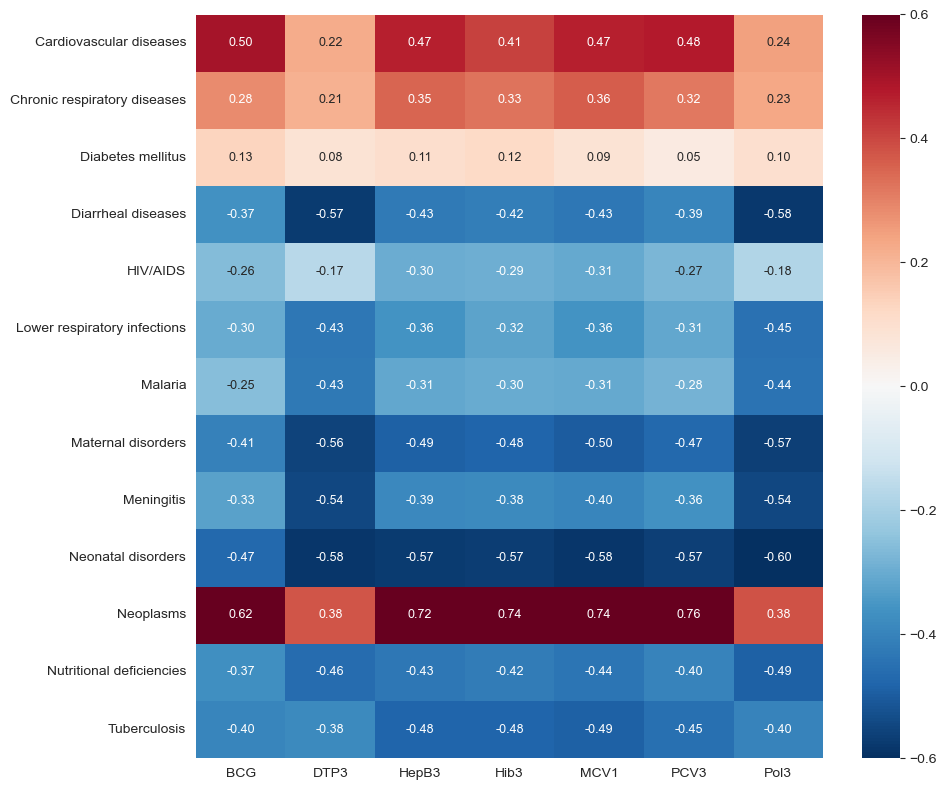

In [15]:
# VACCINATION–MORTALITY PATHWAYS
# ============================================================================

def compute_vaccination_mortality_matrix(dict_data, backend='plotly'):
    df_vacc   = dict_data.get('global_vaccination_coverage')
    df_deaths = dict_data.get('annual_number_of_deaths_by_cause')
    if df_vacc is None or df_deaths is None:
        print("⚠️ Required datasets not found")
        return None, None

    df_merged  = df_vacc.merge(df_deaths, on=['Country', 'Year'], how='inner', suffixes=('_vacc', '_death'))
    vacc_cols  = [c for c in df_vacc.columns if c not in ['Country', 'Year', 'Continent']]
    death_cols = [c for c in df_deaths.columns if c not in ['Country', 'Year', 'Continent']]
    key_vacc   = [c for c in vacc_cols if c in ['DTP3', 'MCV1', 'Pol3', 'HepB3', 'Hib3', 'PCV3', 'BCG']]
    key_deaths = [c for c in death_cols if c in [
        'HIV/AIDS', 'Tuberculosis', 'Malaria', 'Diarrheal diseases',
        'Lower respiratory infections', 'Neonatal disorders', 'Maternal disorders',
        'Meningitis', 'Nutritional deficiencies', 'Cardiovascular diseases',
        'Neoplasms', 'Diabetes mellitus', 'Chronic respiratory diseases'
    ]]

    vacc_in_merged  = [c for c in key_vacc   if c in df_merged.columns]
    death_in_merged = [c for c in key_deaths if c in df_merged.columns]
    if not vacc_in_merged:
        vacc_in_merged  = [c + '_vacc'  for c in key_vacc   if c + '_vacc'  in df_merged.columns]
    if not death_in_merged:
        death_in_merged = [c + '_death' for c in key_deaths if c + '_death' in df_merged.columns]
    if not vacc_in_merged or not death_in_merged:
        print("⚠️ Column matching issue."); return None, None

    corr_matrix = pd.DataFrame(index=death_in_merged, columns=vacc_in_merged, dtype=float)
    pval_matrix = pd.DataFrame(index=death_in_merged, columns=vacc_in_merged, dtype=float)
    for vc in vacc_in_merged:
        for dc in death_in_merged:
            pair = df_merged[[vc, dc]].dropna()
            if len(pair) > 30:
                r, p = stats.pearsonr(pair[vc], pair[dc])
                corr_matrix.loc[dc, vc] = r
                pval_matrix.loc[dc, vc] = p

    clean_rows = [c.replace('_death', '').replace('_vacc', '') for c in corr_matrix.index]
    clean_cols = [c.replace('_death', '').replace('_vacc', '') for c in corr_matrix.columns]
    corr_display = corr_matrix.copy()
    corr_display.index   = clean_rows
    corr_display.columns = clean_cols

    if backend == 'plotly':
        fig = px.imshow(
            corr_display.values.astype(float), x=clean_cols, y=clean_rows,
            color_continuous_scale='RdBu_r', zmin=-0.6, zmax=0.6,
            text_auto='.2f',
            title='Vaccination Coverage vs Cause-Specific Mortality<br>'
                  '<sub>Negative (blue) = more vaccination → fewer deaths</sub>'
        )
        fig.update_layout(height=600, width=800, template='plotly_white')
        fig.show()
    else:
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(corr_display.values.astype(float), xticklabels=clean_cols, yticklabels=clean_rows,
                    cmap='RdBu_r', vmin=-0.6, vmax=0.6, center=0,
                    annot=True, fmt='.2f', annot_kws={'size': 9}, ax=ax)
        plt.tight_layout()
        plt.show()

    return corr_display, pval_matrix


vacc_mort_corr, vacc_mort_pval = compute_vaccination_mortality_matrix(dict_data_agg, backend='matplotlib')

---
# **6. Health Spending Efficiency & Preston Curve**

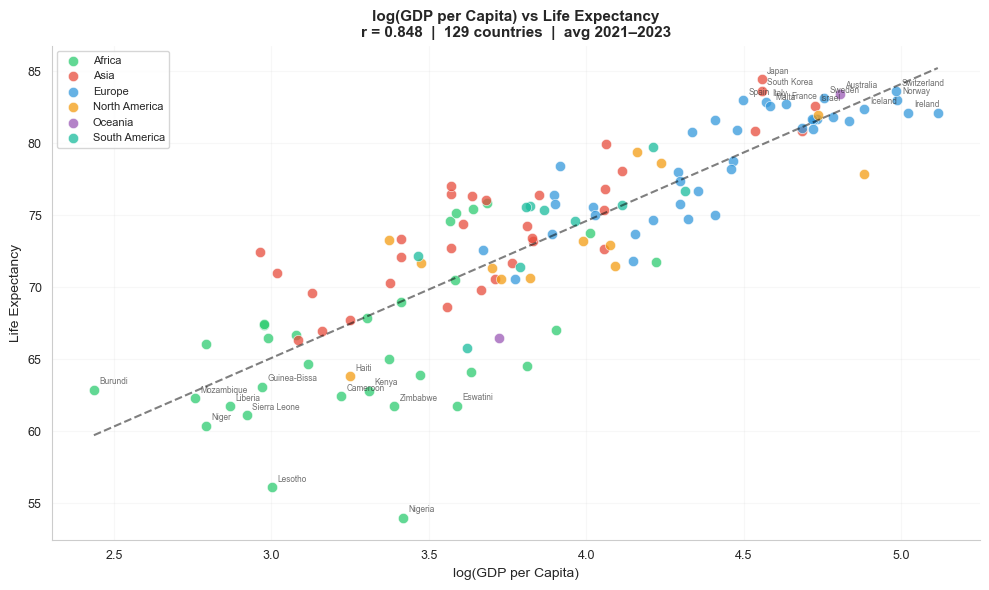

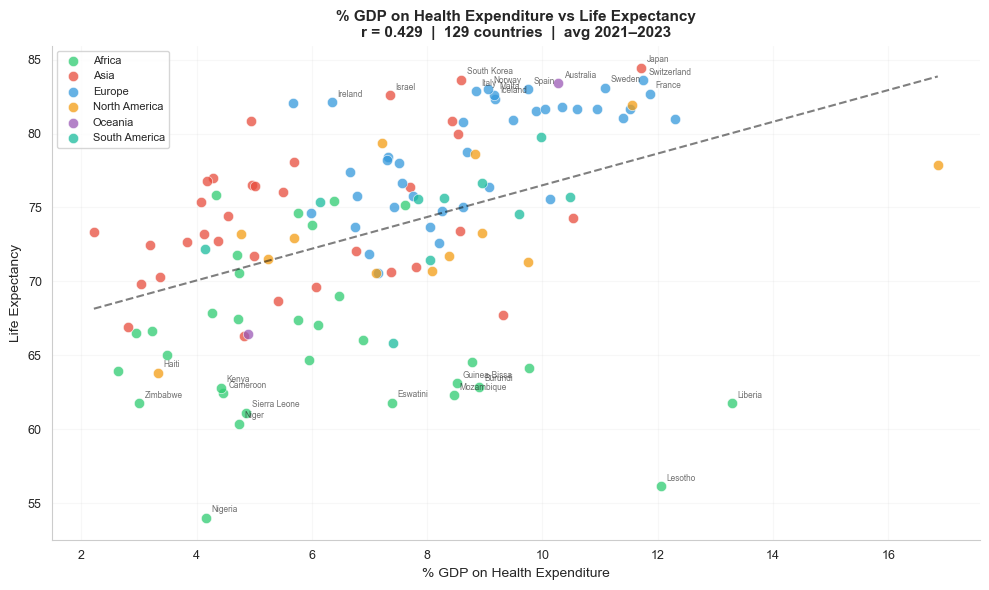

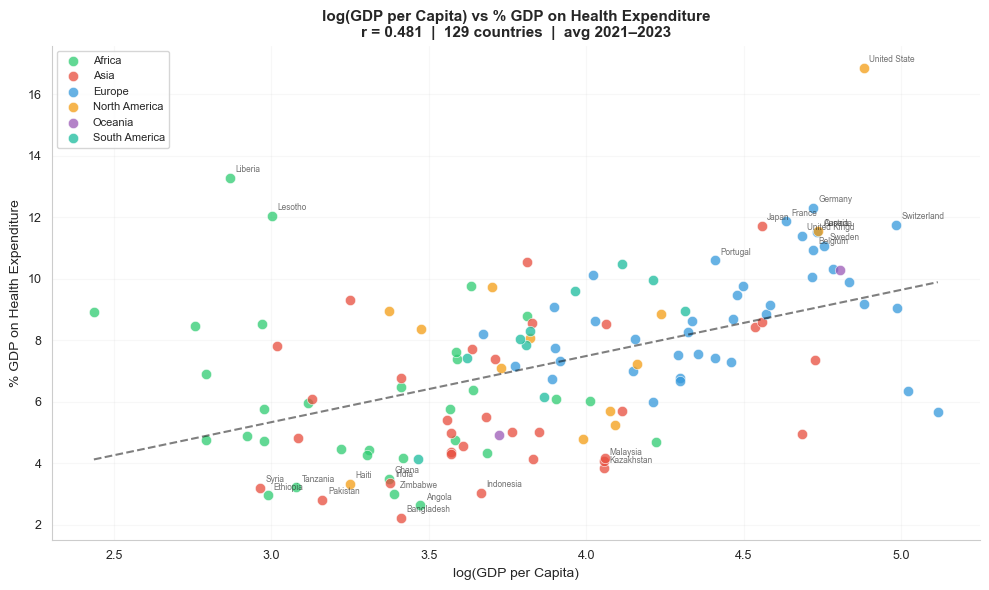


📊 Health Spending Efficiency (129 countries, avg 2021–2023):
   GDP vs LE:              r = 0.848
   Health Spending vs LE:  r = 0.429
   GDP vs Health Spending: r = 0.481


In [16]:
def plot_spending_efficiency(df_panel, target=TARGET, backend='plotly'):
    gdp_col    = [c for c in df_panel.columns if 'GDP per Capita' in c][0]
    health_col = [c for c in df_panel.columns if 'health expenditure' in c.lower()][0]
    recent_years = sorted(df_panel['Year'].unique())[-3:]
    df_recent = (
        df_panel[df_panel['Year'].isin(recent_years)]
        .groupby(['Country', 'Continent'])[[target, gdp_col, health_col]]
        .mean().dropna().reset_index()
    )
    df_recent['log_GDP'] = np.log10(df_recent[gdp_col].clip(lower=1))
    health_clean = health_col.split('__')[-1] if '__' in health_col else health_col

    panels = [
        ('log_GDP',   target,     'log(GDP per Capita)', 'Life Expectancy'),
        (health_col,  target,     health_clean,            'Life Expectancy'),
        ('log_GDP',   health_col, 'log(GDP per Capita)', health_clean),
    ]

    continent_colors = {
        cont: color for cont, color in zip(
            sorted(df_recent['Continent'].unique()),
            ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
        )
    }

    if backend == 'plotly':
        fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.08)
        colors     = px.colors.qualitative.Set2
        continents = sorted(df_recent['Continent'].unique())
        for i, cont in enumerate(continents):
            subset = df_recent[df_recent['Continent'] == cont]
            for col_idx, (x_col, y_col, _, _) in enumerate(panels, start=1):
                fig.add_trace(go.Scatter(
                    x=subset[x_col], y=subset[y_col], mode='markers', name=cont,
                    marker=dict(color=colors[i % len(colors)], size=7, opacity=0.7),
                    legendgroup=cont, showlegend=(col_idx == 1)
                ), row=1, col=col_idx)
        for col_idx, (_, _, x_label, y_label) in enumerate(panels, start=1):
            fig.update_xaxes(title_text=x_label, row=1, col=col_idx)
            fig.update_yaxes(title_text=y_label, row=1, col=col_idx)
        fig.update_layout(
            title='Health Spending Efficiency: GDP → Spending → Life Expectancy',
            height=450, width=1200, template='plotly_white'
        )
        fig.show()

    elif backend == 'matplotlib':
        for x_col, y_col, x_label, y_label in panels:

            fig, ax = plt.subplots(figsize=(10, 6))

            for cont, subset in df_recent.groupby('Continent'):
                ax.scatter(
                    subset[x_col], subset[y_col],
                    label=cont,
                    color=continent_colors.get(cont, 'grey'),
                    s=55, alpha=0.75,
                    edgecolors='white', linewidths=0.5
                )
                # Label outliers (top/bottom 10%)
                for _, row in subset.iterrows():
                    if (row[y_col] < df_recent[y_col].quantile(0.10) or
                            row[y_col] > df_recent[y_col].quantile(0.90)):
                        ax.annotate(
                            row['Country'][:12],
                            (row[x_col], row[y_col]),
                            fontsize=6, alpha=0.65,
                            xytext=(4, 4), textcoords='offset points'
                        )

            # Regression line
            valid = df_recent[[x_col, y_col]].dropna()
            if len(valid) > 5:
                m, b = np.polyfit(valid[x_col], valid[y_col], 1)
                x_range = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
                ax.plot(x_range, m * x_range + b,
                        color='black', linewidth=1.5,
                        linestyle='--', alpha=0.5, label='_nolegend_')

            r = df_recent[x_col].corr(df_recent[y_col])
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel(y_label, fontsize=10)
            ax.set_title(
                f'{x_label} vs {y_label}\n'
                f'r = {r:.3f}  |  {len(df_recent)} countries  |  '
                f'avg {recent_years[0]}–{recent_years[-1]}',
                fontsize=11, fontweight='bold'
            )
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=9)
            ax.legend(fontsize=8, frameon=True,
                      framealpha=0.8, loc='best')
            ax.grid(True, alpha=0.15)

            plt.tight_layout()
            plt.show()

    else:
        raise ValueError(f"Unknown backend '{backend}'. Choose 'plotly' or 'matplotlib'.")

    # Correlations summary
    print(f"\n📊 Health Spending Efficiency ({len(df_recent)} countries, "
          f"avg {recent_years[0]}–{recent_years[-1]}):")
    print(f"   GDP vs LE:              r = {df_recent['log_GDP'].corr(df_recent[target]):.3f}")
    print(f"   Health Spending vs LE:  r = {df_recent[health_col].corr(df_recent[target]):.3f}")
    print(f"   GDP vs Health Spending: r = {df_recent['log_GDP'].corr(df_recent[health_col]):.3f}")
    return df_recent


df_efficiency = plot_spending_efficiency(df_panel_raw, backend='matplotlib')

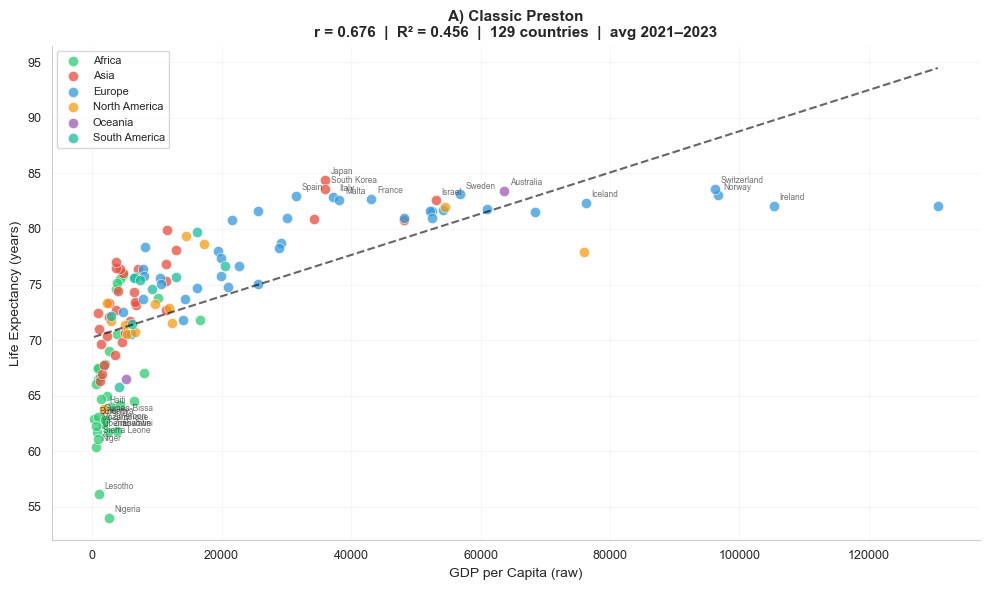

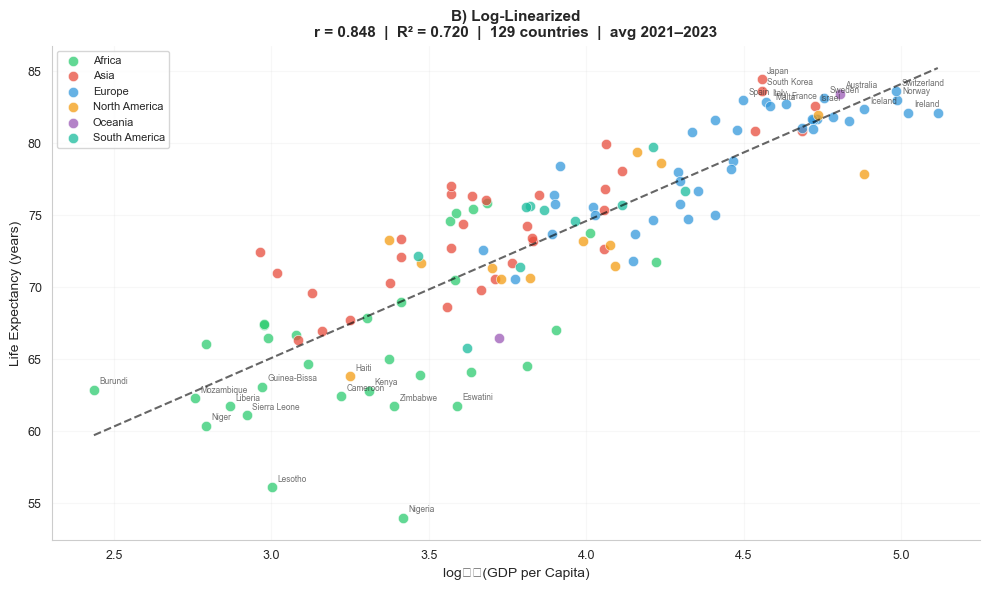

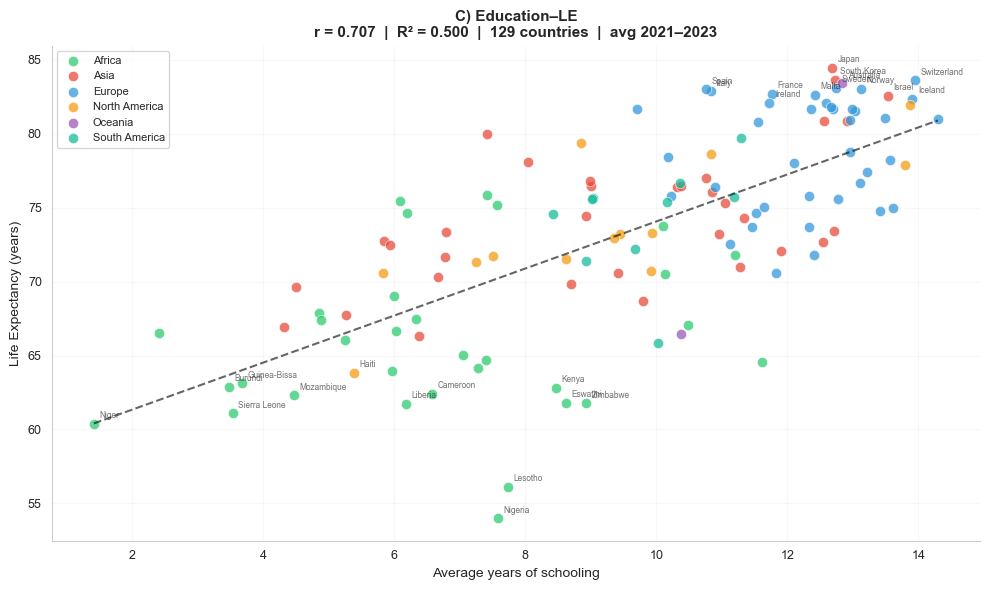


📊 Preston Curve Comparison (129 countries, avg 2021–2023):
   Predictor                        r       R²
   Raw GDP                      0.676    0.456
   log(GDP)                     0.848    0.720
   Years of schooling           0.707    0.500


In [17]:
def plot_preston_vs_education(df_panel, target=TARGET, backend='plotly'):
    gdp_col = [c for c in df_panel.columns if 'GDP per Capita' in c][0]
    edu_col = [c for c in df_panel.columns if 'Average years of schooling' in c][0]
    recent_years = sorted(df_panel['Year'].unique())[-3:]
    df_recent = (
        df_panel[df_panel['Year'].isin(recent_years)]
        .groupby(['Country', 'Continent'])[[target, gdp_col, edu_col]]
        .mean().dropna().reset_index()
    )
    df_recent['log_GDP'] = np.log10(df_recent[gdp_col].clip(lower=1))
    r_raw = df_recent[gdp_col].corr(df_recent[target])
    r_log = df_recent['log_GDP'].corr(df_recent[target])
    r_edu = df_recent[edu_col].corr(df_recent[target])
    edu_clean = edu_col.split('__')[-1] if '__' in edu_col else edu_col

    panels = [
        (gdp_col,   f'A) Classic Preston',   'GDP per Capita (raw)',      r_raw),
        ('log_GDP', f'B) Log-Linearized',    'log₁₀(GDP per Capita)',     r_log),
        (edu_col,   f'C) Education–LE',       edu_clean,                   r_edu),
    ]
    fits = {x_col: np.polyfit(df_recent[x_col].values,
                               df_recent[target].values, 1)
            for x_col, _, _, _ in panels}

    continent_colors = {
        cont: color for cont, color in zip(
            sorted(df_recent['Continent'].unique()),
            ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
        )
    }

    if backend == 'plotly':
        fig = make_subplots(
            rows=1, cols=3,
            subplot_titles=[f'{t} (r={r:.3f})' for _, t, _, r in panels],
            horizontal_spacing=0.07
        )
        colors = px.colors.qualitative.Set2
        for i, cont in enumerate(sorted(df_recent['Continent'].unique())):
            subset = df_recent[df_recent['Continent'] == cont]
            for col_idx, (x_col, _, _, _) in enumerate(panels, start=1):
                fig.add_trace(go.Scatter(
                    x=subset[x_col], y=subset[target], mode='markers', name=cont,
                    marker=dict(color=colors[i % len(colors)], size=7, opacity=0.7),
                    legendgroup=cont, showlegend=(col_idx == 1)
                ), row=1, col=col_idx)
        for col_idx, (x_col, _, x_label, _) in enumerate(panels, start=1):
            x_vals = df_recent[x_col].values
            x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
            fig.add_trace(go.Scatter(
                x=x_line, y=np.polyval(fits[x_col], x_line),
                mode='lines', line=dict(color='black', width=2, dash='dash'),
                showlegend=False
            ), row=1, col=col_idx)
            fig.update_xaxes(title_text=x_label, row=1, col=col_idx)
        fig.update_yaxes(title_text='Life Expectancy (years)', row=1, col=1)
        fig.update_layout(
            title='Redrawing the Preston Curve: GDP vs Education as LE Determinants',
            height=500, width=1300, template='plotly_white'
        )
        fig.show()

    elif backend == 'matplotlib':
        for x_col, title, x_label, r in panels:

            fig, ax = plt.subplots(figsize=(10, 6))

            for cont, subset in df_recent.groupby('Continent'):
                ax.scatter(
                    subset[x_col], subset[target],
                    label=cont,
                    color=continent_colors.get(cont, 'grey'),
                    s=55, alpha=0.75,
                    edgecolors='white', linewidths=0.5
                )
                # Label outliers (top/bottom 10%)
                for _, row in subset.iterrows():
                    if (row[target] < df_recent[target].quantile(0.10) or
                            row[target] > df_recent[target].quantile(0.90)):
                        ax.annotate(
                            row['Country'][:12],
                            (row[x_col], row[target]),
                            fontsize=6, alpha=0.65,
                            xytext=(4, 4), textcoords='offset points'
                        )

            # Regression line
            x_vals = df_recent[x_col].dropna().values
            x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
            ax.plot(x_line, np.polyval(fits[x_col], x_line),
                    color='black', linewidth=1.5,
                    linestyle='--', alpha=0.6, label='_nolegend_')

            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel('Life Expectancy (years)', fontsize=10)
            ax.set_title(
                f'{title}\n'
                f'r = {r:.3f}  |  R² = {r**2:.3f}  |  '
                f'{len(df_recent)} countries  |  '
                f'avg {recent_years[0]}–{recent_years[-1]}',
                fontsize=11, fontweight='bold'
            )
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=9)
            ax.legend(fontsize=8, frameon=True, framealpha=0.8, loc='best')
            ax.grid(True, alpha=0.15)

            plt.tight_layout()
            plt.show()

    else:
        raise ValueError(f"Unknown backend '{backend}'. Choose 'plotly' or 'matplotlib'.")

    # Summary
    print(f"\n📊 Preston Curve Comparison ({len(df_recent)} countries, "
          f"avg {recent_years[0]}–{recent_years[-1]}):")
    print(f"   {'Predictor':<25} {'r':>8} {'R²':>8}")
    print(f"   {'Raw GDP':<25} {r_raw:>8.3f} {r_raw**2:>8.3f}")
    print(f"   {'log(GDP)':<25} {r_log:>8.3f} {r_log**2:>8.3f}")
    print(f"   {'Years of schooling':<25} {r_edu:>8.3f} {r_edu**2:>8.3f}")
    return df_recent


df_preston = plot_preston_vs_education(df_panel_raw, backend='matplotlib')

---
# **7. VIF Analysis — Variance Inflation Factor** *(new)*

VIF measures how much a feature's regression coefficient variance is inflated by collinearity with the other features in the model.

| VIF | Interpretation |
|-----|----------------|
| 1   | No correlation with other features |
| 1–5 | Moderate — generally acceptable |
| 5–10 | High — investigate |
| > 10 | Severe — likely redundant, drop or merge |

We use the cross-sectional snapshot (latest year per country) to avoid inflating N with panel observations, then iterate: compute VIF → drop worst offender → recompute → until all VIFs are below threshold.

In [18]:
# ── 7a. Build cross-sectional snapshot for VIF ────────────────────────────────

# Use the candidate features that survived Phase 2 (strong correlation with LE)
# We'll compute VIF on ALL features first, then on the Phase 2 candidates

# Cross-sectional snapshot: latest year per country
df_cs = df.sort_values('Year').groupby('Country').last().reset_index()

all_numeric = [c for c in df_cs.select_dtypes(include=np.number).columns
               if c not in ['Year'] + [TARGET]]
df_cs_features = df_cs[all_numeric].dropna()

print(f'Cross-sectional snapshot: {df_cs_features.shape[0]} countries × {df_cs_features.shape[1]} features')

# ── 7b. VIF computation function ─────────────────────────────────────────────

def compute_vif(df_features, TOP_LIMIT, BOTTOM_LIMIT):
    """
    Compute VIF for each column. Automatically drops zero-variance columns.
    Returns sorted DataFrame with flag column.
    """
    non_zero = df_features.loc[:, df_features.std() > 0]
    dropped_zero = set(df_features.columns) - set(non_zero.columns)
    if dropped_zero:
        print(f'  ⚠️  Dropped zero-variance columns: {dropped_zero}')

    X = add_constant(non_zero.dropna())
    vif_scores = []
    for i, col in enumerate(X.columns):
        if col == 'const':
            continue
        vif = variance_inflation_factor(X.values, i)
        vif_scores.append({'Feature': col, 'VIF': round(vif, 2)})

    df_vif = pd.DataFrame(vif_scores).sort_values('VIF', ascending=False).reset_index(drop=True)
    df_vif['Flag'] = df_vif['VIF'].apply(
        lambda v: f'🔴 Severe (> {TOP_LIMIT})' if v > TOP_LIMIT else (f'🟡 High ({BOTTOM_LIMIT} – {TOP_LIMIT})' if v > BOTTOM_LIMIT else '🟢 OK')
    )
    return df_vif


Cross-sectional snapshot: 129 countries × 13 features


In [19]:
TOP_LIMIT = 10
BOTTOM_LIMIT = 5

df_vif_all = compute_vif(df_cs_features, TOP_LIMIT, BOTTOM_LIMIT)
print('VIF Scores — All Features')
display(df_vif_all)

severe = df_vif_all[df_vif_all['VIF'] > TOP_LIMIT]['Feature'].tolist()
high   = df_vif_all[(df_vif_all['VIF'] > BOTTOM_LIMIT) & (df_vif_all['VIF'] <= TOP_LIMIT)]['Feature'].tolist()
print(f'\n🔴 Severe VIF (> {TOP_LIMIT}): {severe}')
print(f'🟡 High VIF ({BOTTOM_LIMIT} – {TOP_LIMIT}):  {high}')

VIF Scores — All Features


,Feature,VIF,Flag
0,gini,21169.99,🔴 Severe (> 10)
1,bottom50_share,7490.76,🔴 Severe (> 10)
2,decile10_share,2904.27,🔴 Severe (> 10)
3,Median income or consumption per day,520.64,🔴 Severe (> 10)
4,Mean income or consumption per day,367.71,🔴 Severe (> 10)
5,Share below $3.65 a day,84.08,🔴 Severe (> 10)
6,decile1_share,82.69,🔴 Severe (> 10)
7,Share below $40 a day,71.62,🔴 Severe (> 10)
8,Share below $6.85 a day,54.22,🔴 Severe (> 10)
9,Share below $20 a day,30.20,🔴 Severe (> 10)



🔴 Severe VIF (> 10): ['gini', 'bottom50_share', 'decile10_share', 'Median income or consumption per day', 'Mean income or consumption per day', 'Share below $3.65 a day', 'decile1_share', 'Share below $40 a day', 'Share below $6.85 a day', 'Share below $20 a day', 'Share below $2.15 a day', 'palma_ratio']
🟡 High VIF (5 – 10):  ['p90_p10_ratio']


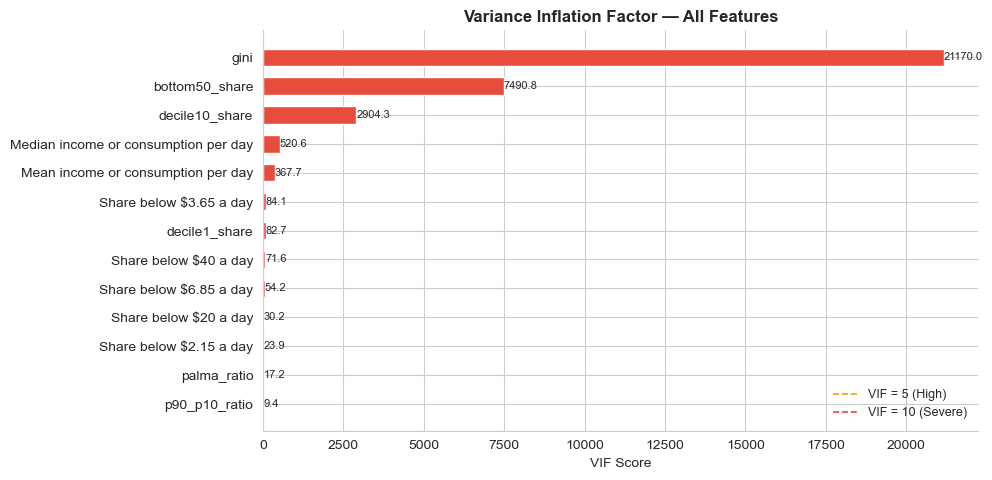

In [20]:
# ── 7c. VIF bar chart ─────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, max(5, len(df_vif_all) * 0.35)))

colors = ['#e74c3c' if v > TOP_LIMIT else ('#f39c12' if v > BOTTOM_LIMIT else '#2ecc71')
          for v in df_vif_all['VIF']]

bars = ax.barh(df_vif_all['Feature'][::-1], df_vif_all['VIF'][::-1],
               color=colors[::-1], edgecolor='white', height=0.6)

ax.axvline(5,  color='#f39c12', linestyle='--', linewidth=1.2, label=f'VIF = {BOTTOM_LIMIT} (High)')
ax.axvline(10, color='#e74c3c', linestyle='--', linewidth=1.2, label=f'VIF = {TOP_LIMIT} (Severe)')

for bar, val in zip(bars, df_vif_all['VIF'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=8)

ax.set_xlabel('VIF Score', fontsize=10)
ax.set_title('Variance Inflation Factor — All Features', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig('vif_all_features.png', dpi=150, bbox_inches='tight')
#print('✅ Saved: vif_all_features.png')
plt.show()


In [21]:
# ── 7d. Iterative VIF pruning — drop worst offender until all VIF < threshold ──

VIF_THRESHOLD = 10  # drop features above this VIF iteratively

def iterative_vif_pruning(df_features, TOP_LIMIT, BOTTOM_LIMIT, threshold=VIF_THRESHOLD, verbose=True):
    """
    Iteratively drop the feature with the highest VIF until all are below threshold.
    Returns the pruned feature list and a log of what was dropped.
    """
    remaining = df_features.copy()
    drop_log  = []
    iteration = 0

    while True:
        df_vif = compute_vif(remaining, TOP_LIMIT, BOTTOM_LIMIT)
        max_vif = df_vif['VIF'].max()
        if max_vif <= threshold:
            break
        worst_feature = df_vif.loc[df_vif['VIF'].idxmax(), 'Feature']
        drop_log.append({'Iteration': iteration + 1, 'Dropped': worst_feature, 'VIF': max_vif})
        remaining = remaining.drop(columns=[worst_feature])
        iteration += 1
        if verbose:
            print(f'  Iter {iteration}: dropped "{worst_feature}" (VIF={max_vif:.1f})')

    final_vif = compute_vif(remaining, TOP_LIMIT, BOTTOM_LIMIT)
    return remaining.columns.tolist(), pd.DataFrame(drop_log), final_vif


print(f'Iterative VIF pruning (threshold = {VIF_THRESHOLD}):')
vif_kept_cols, df_vif_drop_log, df_vif_final = iterative_vif_pruning(df_cs_features, TOP_LIMIT, BOTTOM_LIMIT)

print(f'\n📊 Features dropped by VIF pruning: {len(df_vif_drop_log)}')
display(df_vif_drop_log)

print(f'\n📊 Final VIF scores after pruning ({len(vif_kept_cols)} features remaining):')
display(df_vif_final)

df_vif_final.to_csv('Phase_B_docs/vif_final_scores.csv', index=False)
df_vif_drop_log.to_csv('Phase_B_docs/vif_drop_log.csv', index=False)
#print('✅ Saved: vif_final_scores.csv  |  vif_drop_log.csv')

Iterative VIF pruning (threshold = 10):
  Iter 1: dropped "gini" (VIF=21170.0)
  Iter 2: dropped "Median income or consumption per day" (VIF=520.0)
  Iter 3: dropped "bottom50_share" (VIF=85.2)
  Iter 4: dropped "Share below $3.65 a day" (VIF=82.2)
  Iter 5: dropped "Mean income or consumption per day" (VIF=49.9)
  Iter 6: dropped "Share below $20 a day" (VIF=20.9)
  Iter 7: dropped "decile10_share" (VIF=13.1)

📊 Features dropped by VIF pruning: 7


,Iteration,Dropped,VIF
0,1,gini,21169.99
1,2,Median income or consumption per day,520.05
2,3,bottom50_share,85.18
3,4,Share below $3.65 a day,82.17
4,5,Mean income or consumption per day,49.89
5,6,Share below $20 a day,20.85
6,7,decile10_share,13.08



📊 Final VIF scores after pruning (6 features remaining):


,Feature,VIF,Flag
0,p90_p10_ratio,8.13,🟡 High (5 – 10)
1,palma_ratio,5.17,🟡 High (5 – 10)
2,decile1_share,4.69,🟢 OK
3,Share below $6.85 a day,4.19,🟢 OK
4,Share below $2.15 a day,3.01,🟢 OK
5,Share below $40 a day,1.84,🟢 OK


In [22]:
# ── 7e. VIF on the correlation candidates specifically ────────────────────────
# Compare VIF-flagged features with the multicollinearity clusters found earlier.
# They should largely agree — discrepancies reveal cases where pairwise r < 0.8
# but a feature is still jointly collinear with a group.

print('='*60)
print('VIF vs Pairwise Correlation Cluster Comparison')
print('='*60)

vif_severe_set   = set(severe)
pair_cluster_set = set(df_high_corr['Feature_1'].tolist() + df_high_corr['Feature_2'].tolist())

# In VIF but not in pairwise clusters — these are jointly collinear without any single high pair
vif_only = vif_severe_set - pair_cluster_set
# In pairwise clusters but VIF OK — collinear pair but not inflating the full model badly
pair_only = pair_cluster_set - vif_severe_set

print(f'\n🔴 Severe VIF but NOT in any pairwise cluster (>0.8):')
print(f'   → These are jointly collinear without any single dominant pair')
print(f'   {vif_only if vif_only else "None"}')

print(f'\n🟡 In pairwise cluster (r>0.8) but VIF is OK (< {TOP_LIMIT}):')
print(f'   → Pairwise issue, but not inflating regression badly; may still want to drop one')
print(f'   {pair_only if pair_only else "None"}')

VIF vs Pairwise Correlation Cluster Comparison

🔴 Severe VIF but NOT in any pairwise cluster (>0.8):
   → These are jointly collinear without any single dominant pair
   None

🟡 In pairwise cluster (r>0.8) but VIF is OK (< 10):
   → Pairwise issue, but not inflating regression badly; may still want to drop one
   {'BCG', 'Cirrhosis and other chronic liver diseases', 'PCV3', 'Malaria', 'Hib3', 'Interpersonal violence', 'Life Expectancy', 'Child mortality rate', "Parkinson's disease", 'MCV1', 'Suicide Rate', 'GDP per Capita', 'Diarrheal diseases', 'Tuberculosis', 'Digestive diseases', "Alzheimer's disease and other dementias", 'Homicide Rate', 'Maternal disorders', 'Nutritional deficiencies', 'Neoplasms', 'Protein-energy malnutrition', 'MCV2', 'Average years of schooling', 'DTP3', 'HepB3', 'RotaC', 'Pol3', 'Self-harm', 'p90_p10_ratio', 'Meningitis', 'Neonatal disorders'}


---
# **8. Partial Correlation / Confounding Checks** 

The question: does each feature's correlation with Life Expectancy survive after controlling for GDP per capita?

A feature that loses its correlation after controlling for GDP is likely **proxying for wealth** rather than having an independent effect. A feature that remains significant is a **genuine independent predictor** — much more actionable from a policy perspective.

Method: partial Pearson correlation via residualization — regress both the feature and LE on log(GDP), take the residuals, and correlate those residuals.

In [23]:
# ── 8a. Partial correlation function ─────────────────────────────────────────

def partial_correlation_controlling_for(df, feature_cols, target, control_col):
    """
    Compute partial correlation of each feature with target, controlling for control_col.
    Method: residualize both feature and target on control_col, then correlate residuals.
    Uses cross-sectional snapshot (one row per country).

    Returns DataFrame with raw correlation, partial correlation, and the delta.
    """
    results = []
    lr = LinearRegression()

    for col in feature_cols:
        if col == control_col or col == target:
            continue

        # Drop rows with any NaN across feature, target, or control
        sub = df[[col, target, control_col]].dropna()
        if len(sub) < 20:
            continue

        X_ctrl = sub[[control_col]].values

        # Residualize target on control
        lr.fit(X_ctrl, sub[target].values)
        resid_target = sub[target].values - lr.predict(X_ctrl)

        # Residualize feature on control
        lr.fit(X_ctrl, sub[col].values)
        resid_feature = sub[col].values - lr.predict(X_ctrl)

        # Partial correlation
        if resid_feature.std() == 0:
            continue
        partial_r, partial_p = stats.pearsonr(resid_target, resid_feature)

        # Raw correlation
        raw_r, raw_p = stats.pearsonr(sub[target].values, sub[col].values)

        clean_name = col.split('__')[-1] if '__' in col else col
        results.append({
            'Feature':         clean_name,
            'Full_Col':        col,
            'Raw_r':           round(raw_r, 3),
            'Partial_r':       round(partial_r, 3),
            'Delta':           round(partial_r - raw_r, 3),
            'Raw_p':           round(raw_p, 4),
            'Partial_p':       round(partial_p, 4),
            'N':               len(sub),
            'GDP_Confounded':  '⚠️' if abs(raw_r) > 0.3 and abs(partial_r) < 0.15 else '',
            'Independent':     '✅' if abs(partial_r) > 0.3 else '',
        })

    return pd.DataFrame(results).sort_values('Partial_r', key=abs, ascending=False)

# Use cross-sectional snapshot with log(GDP) as control
df_cs_full = df_panel.sort_values('Year').groupby('Country').last().reset_index()

gdp_col = [c for c in df_cs_full.columns if 'GDP per Capita' in c]
if gdp_col:
    gdp_col = gdp_col[0]
    df_cs_full['log_GDP'] = np.log10(df_cs_full[gdp_col].clip(lower=1))

    feat_cols = [c for c in df_cs_full.select_dtypes(include=np.number).columns
                 if c not in ['Year', TARGET, gdp_col, 'log_GDP']]

    df_partial = partial_correlation_controlling_for(
        df_cs_full, feat_cols, target=TARGET, control_col='log_GDP'
    )

    print('Partial Correlations with Life Expectancy (controlling for log GDP)')
    print('=' * 70)
    display(df_partial[['Feature', 'Raw_r', 'Partial_r', 'Delta', 'GDP_Confounded', 'Independent', 'N']])
else:
    print('⚠️ GDP per Capita column not found — check column names')

Partial Correlations with Life Expectancy (controlling for log GDP)


,Feature,Raw_r,Partial_r,Delta,GDP_Confounded,Independent,N
0,Child mortality rate,-0.918,-0.682,0.236,,✅,129
33,HIV/AIDS,-0.783,-0.619,0.164,,✅,129
38,Meningitis,-0.869,-0.611,0.258,,✅,129
37,Maternal disorders,-0.864,-0.573,0.291,,✅,129
47,Tuberculosis,-0.839,-0.493,0.347,,✅,129
...,...,...,...,...,...,...,...
20,Cardiovascular diseases,0.398,0.037,-0.362,⚠️,,129
6,BCG,0.479,0.036,-0.443,⚠️,,129
16,RotaC,0.588,-0.016,-0.604,⚠️,,129
30,Environmental heat and cold exposure,0.424,-0.011,-0.435,⚠️,,129


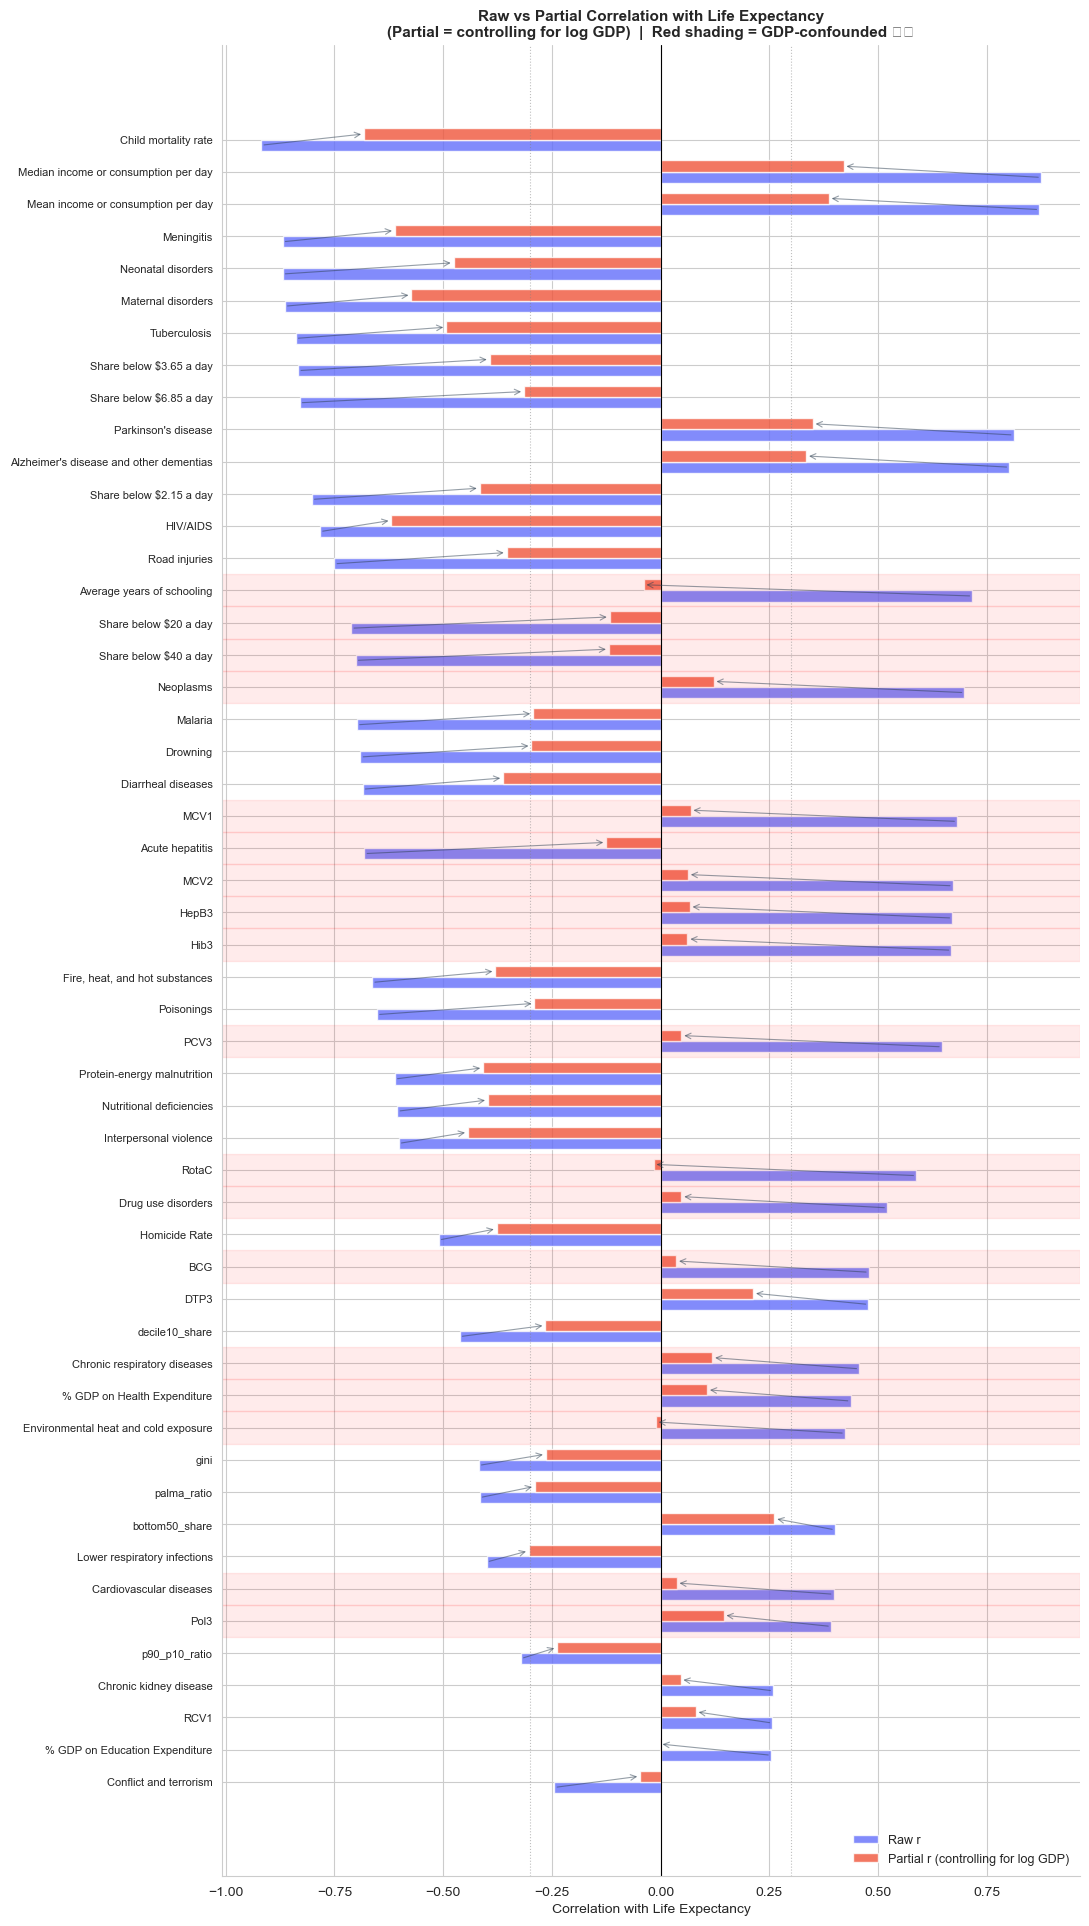

In [24]:
# ── 8b. Visualise raw vs partial correlation — delta plot ─────────────────────

df_partial_plot = df_partial[df_partial['Raw_r'].abs() > 0.2].copy()
df_partial_plot = df_partial_plot.sort_values('Raw_r', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(11, max(6, len(df_partial_plot) * 0.38)))

y_pos = np.arange(len(df_partial_plot))
bar_h = 0.35

ax.barh(y_pos - bar_h/2, df_partial_plot['Raw_r'].values,
        bar_h, color='#636EFA', alpha=0.8, label='Raw r')
ax.barh(y_pos + bar_h/2, df_partial_plot['Partial_r'].values,
        bar_h, color='#EF553B', alpha=0.8, label='Partial r (controlling for log GDP)')

# Draw arrows showing change from raw to partial
for i, (_, row) in enumerate(df_partial_plot.iterrows()):
    ax.annotate('', xy=(row['Partial_r'], i + bar_h/2),
                xytext=(row['Raw_r'], i - bar_h/2),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=0.8, alpha=0.5))

# Highlight GDP-confounded features
for i, (_, row) in enumerate(df_partial_plot.iterrows()):
    if row['GDP_Confounded'] == '⚠️':
        ax.axhspan(i - 0.5, i + 0.5, alpha=0.08, color='red')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_partial_plot['Feature'].values, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.3, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax.axvline(-0.3, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Correlation with Life Expectancy')
ax.set_title('Raw vs Partial Correlation with Life Expectancy\n'
             '(Partial = controlling for log GDP)  |  Red shading = GDP-confounded ⚠️',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9, loc='lower right', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig('partial_correlations_gdp_control.png', dpi=150, bbox_inches='tight')
#print('✅ Saved: partial_correlations_gdp_control.png')
plt.show()


In [25]:
# ── 8c. Summary — GDP-confounded vs independent predictors ────────────────────

confounded  = df_partial[df_partial['GDP_Confounded'] == '⚠️'].sort_values('Raw_r', key=abs, ascending=False)
independent = df_partial[df_partial['Independent']    == '✅'].sort_values('Partial_r', key=abs, ascending=False)

print('='*65)
print('⚠️  GDP-CONFOUNDED: correlation with LE disappears after GDP control')
print('   These features may be proxying for wealth, not independent predictors.')
print('   Use with caution in Phase C — consider dropping or using residuals.')
print('='*65)
display(confounded[['Feature', 'Raw_r', 'Partial_r', 'Delta', 'N']])

print('\n'+'='*65)
print('✅  INDEPENDENT: correlation with LE survives GDP control')
print('   These features have genuine independent predictive power.')
print('   Priority candidates for Phase C modeling.')
print('='*65)
display(independent[['Feature', 'Raw_r', 'Partial_r', 'Delta', 'N']])

df_partial.to_csv('Phase_B_docs/partial_correlations_gdp_control.csv', index=False)
#print('\n✅ Saved: partial_correlations_gdp_control.csv')

⚠️  GDP-CONFOUNDED: correlation with LE disappears after GDP control
   These features may be proxying for wealth, not independent predictors.
   Use with caution in Phase C — consider dropping or using residuals.


,Feature,Raw_r,Partial_r,Delta,N
1,Average years of schooling,0.717,-0.039,-0.756,129
51,Share below $20 a day,-0.711,-0.117,0.594,129
52,Share below $40 a day,-0.701,-0.119,0.582,129
40,Neoplasms,0.699,0.122,-0.577,129
11,MCV1,0.682,0.069,-0.613,129
17,Acute hepatitis,-0.681,-0.125,0.556,129
12,MCV2,0.672,0.063,-0.609,129
9,HepB3,0.671,0.067,-0.605,129
10,Hib3,0.669,0.062,-0.607,129
13,PCV3,0.647,0.048,-0.599,129



✅  INDEPENDENT: correlation with LE survives GDP control
   These features have genuine independent predictive power.
   Priority candidates for Phase C modeling.


,Feature,Raw_r,Partial_r,Delta,N
0,Child mortality rate,-0.918,-0.682,0.236,129
33,HIV/AIDS,-0.783,-0.619,0.164,129
38,Meningitis,-0.869,-0.611,0.258,129
37,Maternal disorders,-0.864,-0.573,0.291,129
47,Tuberculosis,-0.839,-0.493,0.347,129
39,Neonatal disorders,-0.869,-0.476,0.393,129
34,Interpersonal violence,-0.602,-0.443,0.159,129
54,Median income or consumption per day,0.875,0.421,-0.454,129
48,Share below $2.15 a day,-0.802,-0.416,0.386,129
44,Protein-energy malnutrition,-0.611,-0.408,0.202,129


---
# **9. Lag Correlation Analysis**

Health investments (vaccination, health spending, education) likely affect life expectancy with a delay — e.g., a child vaccinated in 2005 contributes to reduced mortality over the following decade. Contemporaneous correlations may therefore understate the true importance of these variables.

We compute correlations between lagged features (at 1-year and 3-year lags) and current Life Expectancy, and compare against the lag-0 (contemporaneous) baseline.

In [26]:
# ── 9a. Lag correlation computation ──────────────────────────────────────────

# Features most likely to have delayed effects
LAG_CANDIDATES = [
    'DTP3', 'MCV1', 'HepB3', 'Hib3', 'PCV3', 'Pol3', 'BCG',      # vaccination
    '% GDP on Health Expenditure', '% GDP on Education Expenditure', # spending
    'Average years of schooling',                                     # education
    'GDP per Capita',                                                 # economic
]
LAGS = [0, 1, 2, 3]


def compute_lag_correlations(df_panel, lag_candidates, target=TARGET, lags=LAGS):
    """
    For each candidate feature and each lag, compute the within-country
    correlation between lagged feature and current LE.

    lag=0 is the contemporaneous baseline.
    lag=k means feature value at time t-k vs LE at time t.
    """
    results = []

    # Resolve column names — candidates may be clean names, panel may have dataset__ prefix
    col_map = {}
    for cand in lag_candidates:
        if cand in df_panel.columns:
            col_map[cand] = cand
        else:
            matches = [c for c in df_panel.columns if c.split('__')[-1] == cand]
            if matches:
                col_map[cand] = matches[0]

    if not col_map:
        print('⚠️ None of the lag candidates found in df_panel. Check column names.')
        return pd.DataFrame()

    print(f'Resolved {len(col_map)}/{len(lag_candidates)} lag candidates in df_panel')

    for cand_clean, col in col_map.items():
        for lag in lags:
            lag_corrs = []
            for country, grp in df_panel.groupby('Country'):
                grp = grp.sort_values('Year').copy()
                grp['feature_lagged'] = grp[col].shift(lag)
                pair = grp[[target, 'feature_lagged']].dropna()
                if len(pair) < 8:
                    continue
                r, _ = stats.pearsonr(pair[target], pair['feature_lagged'])
                lag_corrs.append(r)

            if lag_corrs:
                results.append({
                    'Feature':       cand_clean,
                    'Lag':           lag,
                    'Mean_r':        round(np.mean(lag_corrs), 3),
                    'Median_r':      round(np.median(lag_corrs), 3),
                    'Std_r':         round(np.std(lag_corrs), 3),
                    'N_Countries':   len(lag_corrs),
                })

    return pd.DataFrame(results)


df_lag_corr = compute_lag_correlations(df_panel, LAG_CANDIDATES)

print('\n📊 Lag Correlation Results (within-country average):')
display(df_lag_corr.sort_values(['Feature', 'Lag']))

Resolved 11/11 lag candidates in df_panel

📊 Lag Correlation Results (within-country average):


,Feature,Lag,Mean_r,Median_r,Std_r,N_Countries
32,% GDP on Education Expenditure,0,0.041,0.017,0.518,115
33,% GDP on Education Expenditure,1,0.033,0.033,0.513,115
34,% GDP on Education Expenditure,2,0.091,0.081,0.498,114
35,% GDP on Education Expenditure,3,0.133,0.175,0.485,111
28,% GDP on Health Expenditure,0,0.392,0.430,0.290,129
29,% GDP on Health Expenditure,1,0.368,0.410,0.294,129
30,% GDP on Health Expenditure,2,0.435,0.473,0.263,129
31,% GDP on Health Expenditure,3,0.407,0.447,0.298,129
36,Average years of schooling,0,0.786,0.894,0.252,129
37,Average years of schooling,1,0.774,0.888,0.265,129


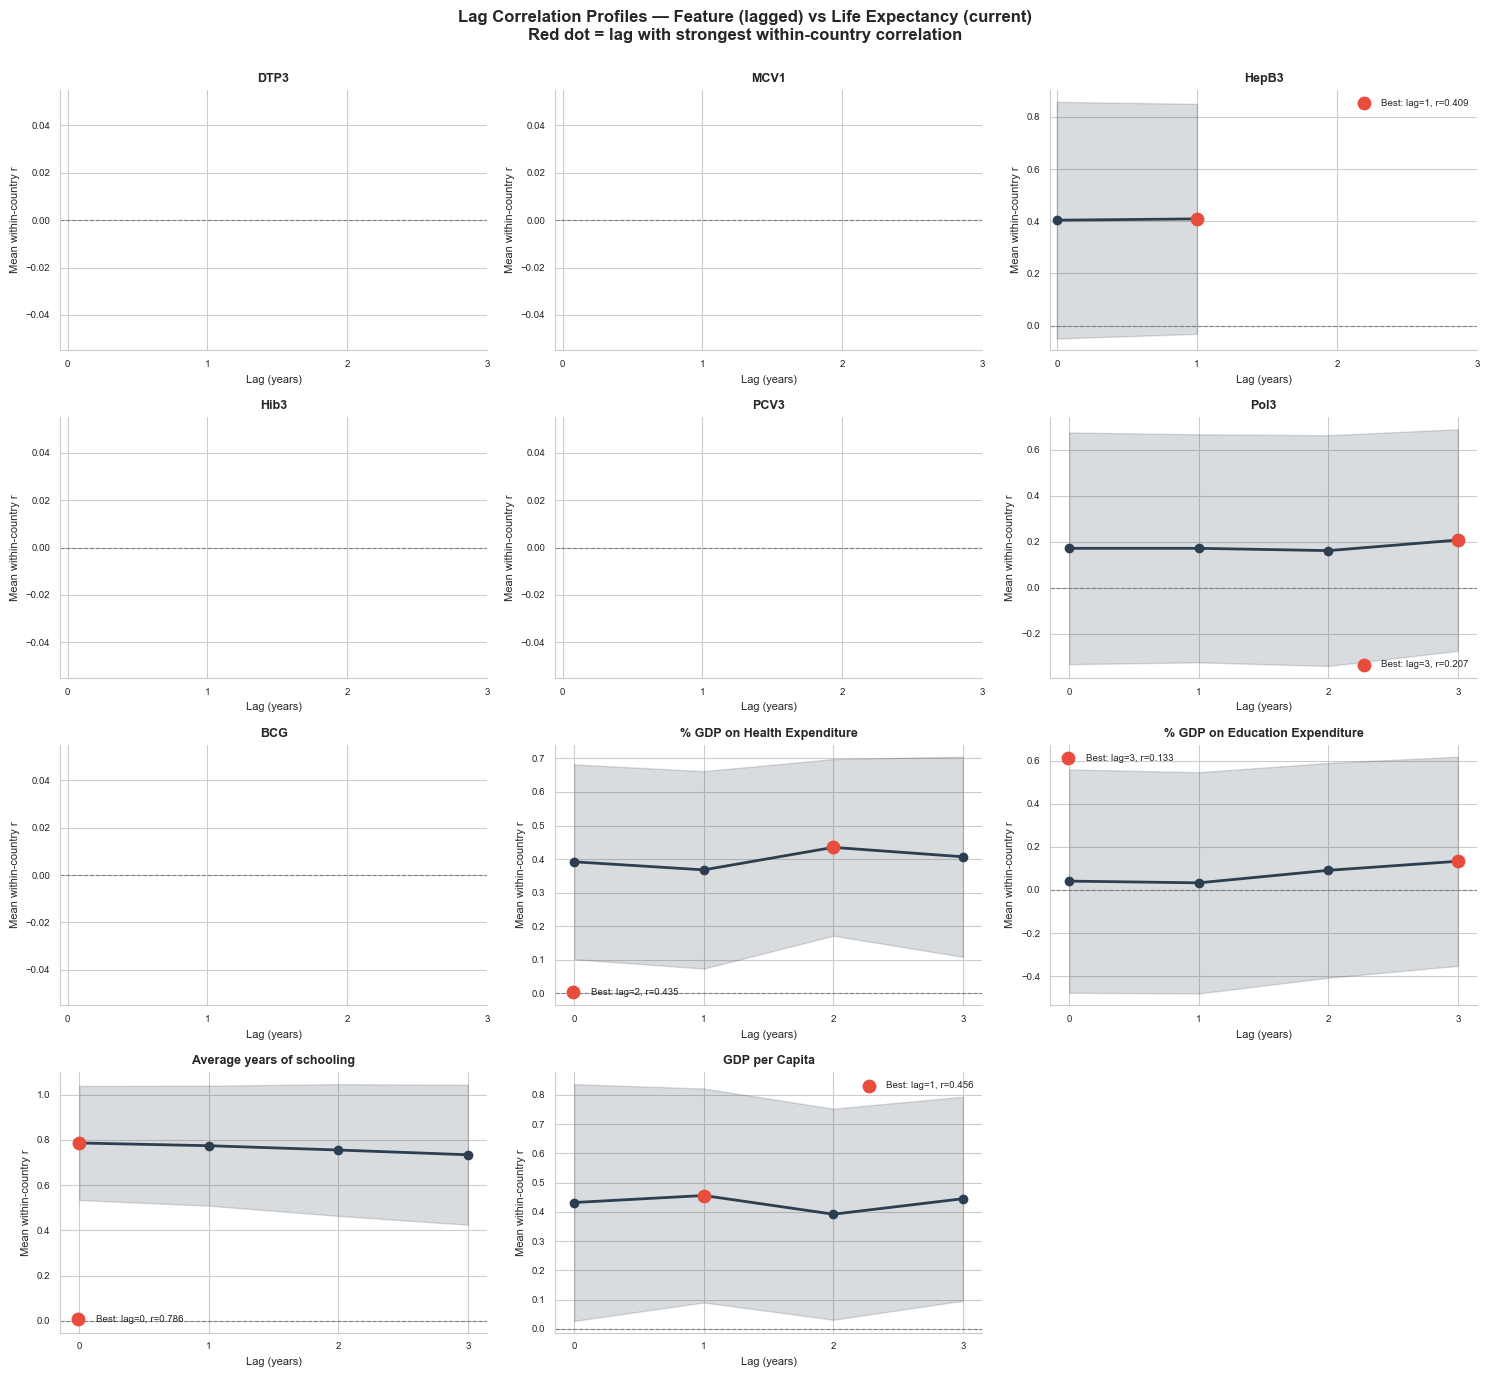

In [27]:
# ── 9b. Lag profile plot — how correlation changes with lag ───────────────────

features_with_data = df_lag_corr['Feature'].unique()
ncols = 3
nrows = int(np.ceil(len(features_with_data) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5), sharey=False)
axes = axes.flatten()

for ax, feat in zip(axes, features_with_data):
    feat_data = df_lag_corr[df_lag_corr['Feature'] == feat].sort_values('Lag')
    lags      = feat_data['Lag'].values
    mean_r    = feat_data['Mean_r'].values
    std_r     = feat_data['Std_r'].values

    ax.plot(lags, mean_r, 'o-', color='#2c3e50', linewidth=2, markersize=6)
    ax.fill_between(lags, mean_r - std_r, mean_r + std_r,
                    alpha=0.18, color='#2c3e50')

    # Highlight the lag with the strongest correlation
    feat_valid = feat_data.dropna(subset=['Mean_r'])
    if len(feat_valid) > 0:
        best_idx = feat_valid['Mean_r'].abs().idxmax()
        best_lag = feat_valid.loc[best_idx, 'Lag']
        best_r   = feat_valid.loc[best_idx, 'Mean_r']
        ax.scatter([best_lag], [best_r], color='#e74c3c', s=80, zorder=5,
                   label=f'Best: lag={best_lag}, r={best_r:.3f}')

    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xticks(LAGS)
    ax.set_xlabel('Lag (years)', fontsize=8)
    ax.set_ylabel('Mean within-country r', fontsize=8)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, frameon=False)
    ax.tick_params(labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

for ax in axes[len(features_with_data):]:
    ax.set_visible(False)

plt.suptitle('Lag Correlation Profiles — Feature (lagged) vs Life Expectancy (current)\n'
             'Red dot = lag with strongest within-country correlation',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig('lag_correlation_profiles.png', dpi=150, bbox_inches='tight')
#print('✅ Saved: lag_correlation_profiles.png')
plt.show()


In [28]:
# ── 9c. Lag summary — which features strengthen with lag, which weaken ─────────

lag_summary = []
for feat in features_with_data:
    feat_data  = df_lag_corr[df_lag_corr['Feature'] == feat].sort_values('Lag')
    feat_valid = feat_data.dropna(subset=['Mean_r'])
    r_lag0     = feat_data[feat_data['Lag'] == 0]['Mean_r'].values
    r_lag1     = feat_data[feat_data['Lag'] == 1]['Mean_r'].values
    r_lag3     = feat_data[feat_data['Lag'] == 3]['Mean_r'].values
    best_row   = feat_valid.loc[feat_valid['Mean_r'].abs().idxmax()] if len(feat_valid) > 0 else feat_data.iloc[0]

    r0 = float(r_lag0[0]) if len(r_lag0) else np.nan
    r1 = float(r_lag1[0]) if len(r_lag1) else np.nan
    r3 = float(r_lag3[0]) if len(r_lag3) else np.nan

    strengthens = (not np.isnan(r0)) and (not np.isnan(r3)) and (abs(r3) > abs(r0) + 0.02)
    weakens     = (not np.isnan(r0)) and (not np.isnan(r3)) and (abs(r3) < abs(r0) - 0.02)

    lag_summary.append({
        'Feature':          feat,
        'r @ lag=0':        round(r0, 3),
        'r @ lag=1':        round(r1, 3),
        'r @ lag=3':        round(r3, 3),
        'Best lag':         int(best_row['Lag']),
        'Best r':           round(float(best_row['Mean_r']), 3),
        'Pattern':          '📈 Strengthens with lag' if strengthens else
                            ('📉 Weakens with lag' if weakens else '➡️  Stable'),
        'Rec. in Phase C':  f'Use lag={int(best_row["Lag"])}' if strengthens else 'Use contemporaneous (lag=0)'
    })

df_lag_summary = pd.DataFrame(lag_summary)
print('Lag Correlation Summary:')
display(df_lag_summary)

df_lag_corr.to_csv('Phase_B_docs/lag_correlations.csv', index=False)
df_lag_summary.to_csv('Phase_B_docs/lag_correlation_summary.csv', index=False)
#print('\n✅ Saved: lag_correlations.csv  |  lag_correlation_summary.csv')

Lag Correlation Summary:


,Feature,r @ lag=0,r @ lag=1,r @ lag=3,Best lag,Best r,Pattern,Rec. in Phase C
0,DTP3,NaN,NaN,NaN,0,NaN,➡️ Stable,Use contemporaneous (lag=0)
1,MCV1,NaN,NaN,NaN,0,NaN,➡️ Stable,Use contemporaneous (lag=0)
2,HepB3,0.404,0.409,NaN,1,0.409,➡️ Stable,Use contemporaneous (lag=0)
3,Hib3,NaN,NaN,NaN,0,NaN,➡️ Stable,Use contemporaneous (lag=0)
4,PCV3,NaN,NaN,NaN,0,NaN,➡️ Stable,Use contemporaneous (lag=0)
5,Pol3,0.171,0.171,0.207,3,0.207,📈 Strengthens with lag,Use lag=3
6,BCG,NaN,NaN,NaN,0,NaN,➡️ Stable,Use contemporaneous (lag=0)
7,% GDP on Health Expenditure,0.392,0.368,0.407,2,0.435,➡️ Stable,Use contemporaneous (lag=0)
8,% GDP on Education Expenditure,0.041,0.033,0.133,3,0.133,📈 Strengthens with lag,Use lag=3
9,Average years of schooling,0.786,0.774,0.734,0,0.786,📉 Weakens with lag,Use contemporaneous (lag=0)


---
# **10. Preliminary Random Forest Importance**

Before locking in the Phase C feature set, we run a quick Random Forest to cross-validate the correlation-based ranking. This catches cases where:
- A feature has high pairwise correlation but adds no **conditional** predictive value (correlation-based ranking overcounts it)
- A feature has moderate correlation but strong **interaction effects** with others (correlation-based ranking undercounts it)

We use permutation importance (not impurity-based) to avoid inflating the importance of high-cardinality or continuous features. Cross-validation guards against overfitting on the small cross-sectional dataset.

In [29]:
# ── 10a. Prepare feature matrix ──────────────────────────────────────────────

ID_COLS = ['Country', 'Continent', 'Year']

# Use df_panel (full merged panel) — not df which may be reassigned
TARGET_COL = [c for c in df_panel.columns if 'Life Expectancy' in c]
if not TARGET_COL:
    raise ValueError(f"No 'Life Expectancy' column found. "
                     f"Available: {df_panel.columns.tolist()}")
TARGET_COL = TARGET_COL[0]
print(f"Resolved TARGET column: '{TARGET_COL}'")

# Cross-sectional snapshot — latest year per country
df_rf = df_panel.sort_values('Year').groupby('Country').last().reset_index()

feat_cols_rf = [
    c for c in df_rf.select_dtypes(include=np.number).columns
    if c not in ID_COLS + ['Year', TARGET_COL]
]

# Keep only rows with complete data
df_rf_clean = df_rf[feat_cols_rf + [TARGET_COL]].dropna()
X = df_rf_clean[feat_cols_rf].values
y = df_rf_clean[TARGET_COL].values

print(f'RF dataset: {X.shape[0]} countries × {X.shape[1]} features')
print(f'Target: {TARGET_COL}  |  Range: {y.min():.1f}–{y.max():.1f} years')

Resolved TARGET column: 'Life Expectancy'
RF dataset: 125 countries × 62 features
Target: Life Expectancy  |  Range: 54.5–84.7 years


In [30]:
# ── 10b. Cross-validated RF + permutation importance ──────────────────────────

RF_PARAMS = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf = RandomForestRegressor(**RF_PARAMS)

# Cross-validated R² to assess overall model quality
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='r2')

print(f'Cross-validated R² (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'Individual folds: {[round(s, 3) for s in cv_scores]}')

# Fit on full dataset for permutation importance
rf.fit(X, y)
print(f'\n✅ RF fitted on full dataset')
print(f'   In-sample R²: {rf.score(X, y):.3f}')

Cross-validated R² (5-fold): 0.875 ± 0.056
Individual folds: [np.float64(0.853), np.float64(0.823), np.float64(0.94), np.float64(0.943), np.float64(0.816)]

✅ RF fitted on full dataset
   In-sample R²: 0.962


In [31]:
# ── 10c. Permutation importance ───────────────────────────────────────────────

perm_imp = permutation_importance(
    rf, X, y,
    n_repeats=30,
    random_state=42,
    scoring='r2'
)

df_rf_imp = pd.DataFrame({
    'Feature':       feat_cols_rf,
    'Importance':    perm_imp.importances_mean,
    'Std':           perm_imp.importances_std,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

df_rf_imp['Rank_RF'] = df_rf_imp.index + 1

# Clean feature names for display
df_rf_imp['Feature_Clean'] = df_rf_imp['Feature'].apply(
    lambda c: c.split('__')[-1] if '__' in c else c
)

print('📊 Permutation Importance:')
display(df_rf_imp[['Rank_RF', 'Feature_Clean', 'Importance', 'Std']].head(50))

📊 Permutation Importance:


,Rank_RF,Feature_Clean,Importance,Std
0,1,Child mortality rate,0.029756,0.004077
1,2,Meningitis,0.025342,0.003660
2,3,Median income or consumption per day,0.021207,0.003664
3,4,Share below $3.65 a day,0.017820,0.003749
4,5,Share below $6.85 a day,0.015499,0.003024
5,6,Maternal disorders,0.011882,0.002251
6,7,Mean income or consumption per day,0.011634,0.002231
7,8,GDP per Capita,0.010907,0.001655
8,9,Share below $40 a day,0.009313,0.001836
9,10,Neonatal disorders,0.008532,0.001649


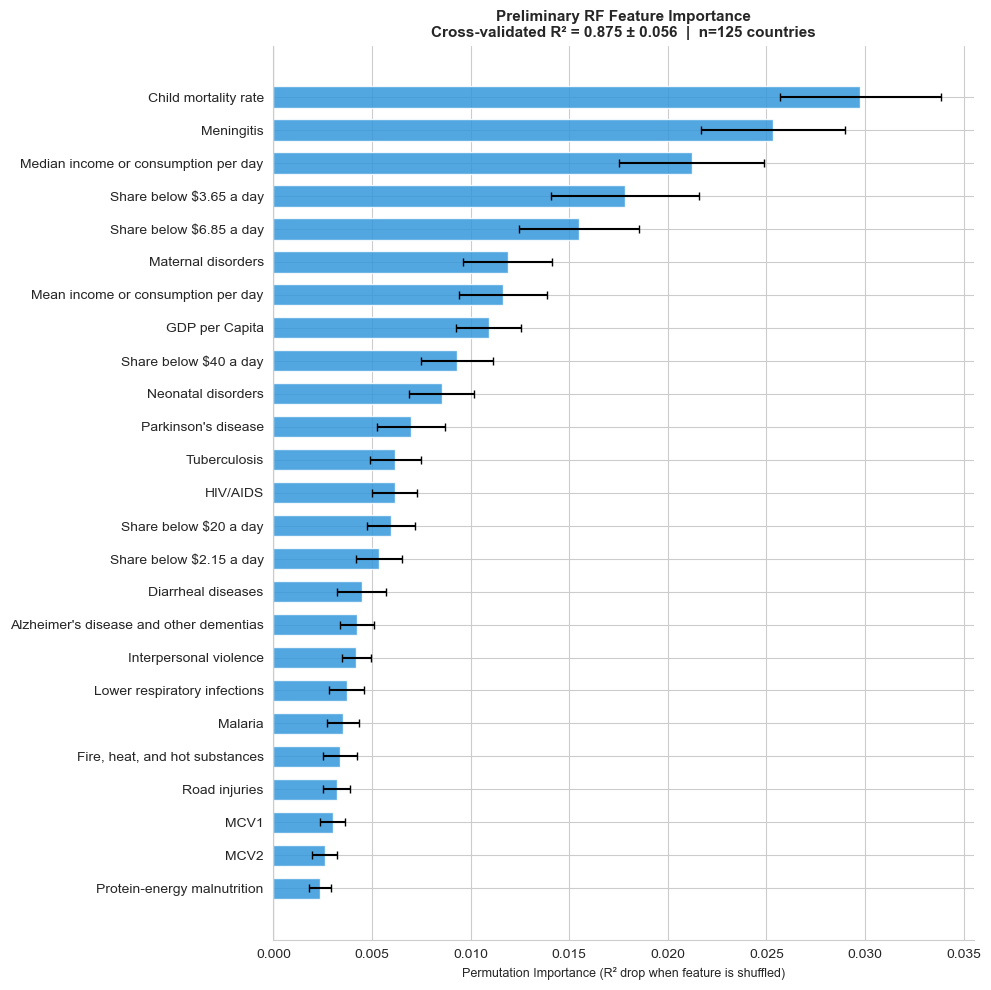

In [32]:
# ── 10d. RF importance bar chart ──────────────────────────────────────────────

top_rf = df_rf_imp[df_rf_imp['Importance'] > 0].head(25)

fig, ax = plt.subplots(figsize=(10, max(5, len(top_rf) * 0.4)))

ax.barh(top_rf['Feature_Clean'][::-1], top_rf['Importance'][::-1],
        xerr=top_rf['Std'][::-1], capsize=3,
        color='#3498db', edgecolor='white', alpha=0.85, height=0.65)

ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Permutation Importance (R² drop when feature is shuffled)', fontsize=9)
ax.set_title(f'Preliminary RF Feature Importance\n'
             f'Cross-validated R² = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  |  n={len(y)} countries',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
#plt.savefig('rf_permutation_importance.png', dpi=150, bbox_inches='tight')
#print('✅ Saved: rf_permutation_importance.png')
plt.show()


In [33]:
# ── 10e. Rank comparison: Correlation vs RF ────────────────────────────────────
# Find features where RF rank differs substantially from correlation rank.
# These are the most interesting cases — features that correlation misses or overcounts.

# Build correlation ranking (use absolute Pearson with LE)
corr_with_le = (
    df_panel.select_dtypes(include=np.number)
    .corrwith(df_panel[TARGET])
    .abs()
    .drop([TARGET, 'Year'], errors='ignore')
    .sort_values(ascending=False)
    .reset_index()
)
corr_with_le.columns = ['Feature', 'Abs_Corr']
corr_with_le['Rank_Corr'] = corr_with_le.index + 1
corr_with_le['Feature_Clean'] = corr_with_le['Feature'].apply(
    lambda c: c.split('__')[-1] if '__' in c else c
)

# Merge on clean name
df_rank_compare = df_rf_imp[['Feature_Clean', 'Rank_RF', 'Importance']].merge(
    corr_with_le[['Feature_Clean', 'Rank_Corr', 'Abs_Corr']],
    on='Feature_Clean', how='inner'
)

df_rank_compare['Rank_Delta'] = df_rank_compare['Rank_Corr'] - df_rank_compare['Rank_RF']
df_rank_compare = df_rank_compare.sort_values('Rank_RF')

print('Rank Comparison: Correlation-based vs RF Permutation Importance')
print('Rank_Delta > 0 = correlation underestimates RF importance (feature is more important than correlation suggests)')
print('Rank_Delta < 0 = correlation overestimates RF importance (feature is less useful conditionally)')
print()
display(df_rank_compare[['Feature_Clean', 'Rank_RF', 'Importance', 'Rank_Corr', 'Abs_Corr', 'Rank_Delta']])

large_delta = df_rank_compare[df_rank_compare['Rank_Delta'].abs() > 5].sort_values('Rank_Delta', key=abs, ascending=False)
if len(large_delta):
    print(f'\n⚠️  Features with large rank discrepancy (|Rank_Delta| > 5):')
    display(large_delta[['Feature_Clean', 'Rank_RF', 'Rank_Corr', 'Rank_Delta']])

df_rank_compare.to_csv('Phase_B_docs/rf_vs_correlation_ranking.csv', index=False)
df_rf_imp.to_csv('Phase_B_docs/rf_permutation_importance.csv', index=False)
#print('\n✅ Saved: rf_permutation_importance.csv  |  rf_vs_correlation_ranking.csv')

Rank Comparison: Correlation-based vs RF Permutation Importance
Rank_Delta > 0 = correlation underestimates RF importance (feature is more important than correlation suggests)
Rank_Delta < 0 = correlation overestimates RF importance (feature is less useful conditionally)



,Feature_Clean,Rank_RF,Importance,Rank_Corr,Abs_Corr,Rank_Delta
0,Child mortality rate,1,0.029756,1,0.931954,0
1,Meningitis,2,0.025342,2,0.896152,0
2,Median income or consumption per day,3,0.021207,6,0.845236,3
3,Share below $3.65 a day,4,0.017820,9,0.811074,5
4,Share below $6.85 a day,5,0.015499,13,0.771162,8
...,...,...,...,...,...,...
57,Self-harm,58,0.000431,58,0.133638,0
58,p90_p10_ratio,59,0.000384,47,0.315412,-12
59,decile1_share,60,0.000381,55,0.199302,-5
60,Suicide Rate,61,0.000334,49,0.273487,-12



⚠️  Features with large rank discrepancy (|Rank_Delta| > 5):


,Feature_Clean,Rank_RF,Rank_Corr,Rank_Delta
17,Interpersonal violence,18,42,24
29,Conflict and terrorism,30,53,23
32,Cirrhosis and other chronic liver diseases,33,54,21
37,Average years of schooling,38,19,-19
52,Pol3,53,34,-19
8,Share below $40 a day,9,28,19
33,Alcohol use disorders,34,51,17
46,HepB3,47,30,-17
26,Cardiovascular diseases,27,43,16
36,Neoplasms,37,21,-16


---
# **11. Candidate Selection — 8-Phase Pipeline**

**Phase 1:** Flatten `results_pearson` and `results_spearman` into a single master correlation table.

**Phase 2:** Apply correlation strength filter — keep only variables where both `|Pearson| > 0.3` AND `|Spearman| > 0.3` with Life Expectancy.

In [34]:

# PHASE 1 — Build master correlation table
# ============================================================================

EXCLUDE_VARS = ['Life Expectancy']
rows = []

for dataset_key, vars_dict_p in results_pearson.items():
    vars_dict_s = results_spearman.get(dataset_key, {})
    for var_name, stats_p in vars_dict_p.items():
        if var_name in EXCLUDE_VARS:
            continue
        stats_s = vars_dict_s.get(var_name)
        if stats_s is None:
            continue
        pearson_r  = float(stats_p['correlation'])
        spearman_r = float(stats_s['correlation'])
        rows.append({
            'Variable':     var_name,
            'Dataset':      dataset_key,
            'Pearson':      round(pearson_r,  3),
            'Spearman':     round(spearman_r, 3),
            'Abs_Pearson':  round(abs(pearson_r),  3),
            'Abs_Spearman': round(abs(spearman_r), 3),
            'Abs_Max':      round(max(abs(pearson_r), abs(spearman_r)), 3),
        })

df_master = pd.DataFrame(rows).sort_values('Abs_Max', ascending=False).reset_index(drop=True)
print(f'✅ Phase 1: {len(df_master)} variables across {df_master["Dataset"].nunique()} datasets')
display(df_master.head(20)[['Variable', 'Dataset', 'Pearson', 'Spearman', 'Abs_Max']])

# PHASE 2 — Correlation strength filter
THRESHOLD    = 0.3
mask_pass    = (df_master['Abs_Pearson'] > THRESHOLD) & (df_master['Abs_Spearman'] > THRESHOLD)
df_candidates  = df_master[mask_pass].copy().reset_index(drop=True)
df_filtered    = df_master[~mask_pass].copy().reset_index(drop=True)

print(f'\n✅ Phase 2: {len(df_candidates)} passed | {len(df_filtered)} dropped (threshold={THRESHOLD})')
display(df_candidates[['Variable', 'Dataset', 'Pearson', 'Spearman', 'Abs_Max']])

# PHASE 3 — Join robustness signal from df_cross_vs_within
# ============================================================================

cross_cols       = ['Variable', 'Cross_Sectional_r', 'Within_Country_r', 'Both_Strong', 'Cross_Only']
df_cross_lookup  = df_cross_vs_within[cross_cols].drop_duplicates('Variable')
df_candidates    = df_candidates.merge(df_cross_lookup, on='Variable', how='left')

matched   = df_candidates['Cross_Sectional_r'].notna().sum()
unmatched = df_candidates['Cross_Sectional_r'].isna().sum()
print(f'✅ Phase 3: {matched} matched | {unmatched} unmatched')

# PHASE 4 — Join non-linearity flag
nonlinear_cols    = ['Variable', 'Abs_Diff', 'Non_Linear_Flag']
df_nl_lookup      = df_comparison[nonlinear_cols].drop_duplicates('Variable')
df_candidates     = df_candidates.merge(df_nl_lookup, on='Variable', how='left')
df_candidates['Non_Linear_Flag'] = df_candidates['Non_Linear_Flag'].fillna('')
df_candidates['Abs_Diff']        = df_candidates['Abs_Diff'].fillna(0)

flagged_nl = df_candidates[df_candidates['Non_Linear_Flag'] == '⚠️']
print(f'\n✅ Phase 4: {len(flagged_nl)} non-linear variables flagged for log-transform')
display(df_candidates[[
    'Variable', 'Dataset', 'Pearson', 'Spearman', 'Abs_Max',
    'Cross_Sectional_r', 'Within_Country_r', 'Both_Strong', 'Cross_Only', 'Non_Linear_Flag'
]])

# PHASE 4.5 — Join partial correlation and apply independence filter
partial_cols = ['Feature', 'Partial_r', 'GDP_Confounded', 'Independent']
df_partial_lookup = df_partial[partial_cols].drop_duplicates('Feature')\
    .rename(columns={'Feature': 'Variable'})  # ← BUG 1 FIX: rename so merge key matches
df_candidates = df_candidates.merge(df_partial_lookup, on='Variable', how='left')

KEEP_CONFOUNDED = False
if not KEEP_CONFOUNDED:
    before = len(df_candidates)
    df_candidates = df_candidates[df_candidates['GDP_Confounded'] != '⚠️'].copy()
    print(f'Phase 4.5: dropped {before - len(df_candidates)} GDP-confounded variables')

# PHASE 5 — Deduplicate multicollinear clusters (keep top N per cluster)
MAX_PER_CLUSTER  = 4
CLUSTER_CORR_THR = 0.90  # ← filter df_high_corr to only truly redundant pairs

neighbors = defaultdict(set)
for _, row in df_high_corr.iterrows():
    if abs(row['Correlation']) < CLUSTER_CORR_THR:
        continue   # ← skip weak pairs that cause cross-cluster chaining
    neighbors[row['Feature_1']].add(row['Feature_2'])
    neighbors[row['Feature_2']].add(row['Feature_1'])

visited   = set()
clusters  = {}
cluster_id = 0
for feature in neighbors:
    if feature not in visited:
        queue = [feature]; visited.add(feature); members = []
        while queue:
            node = queue.pop(0); members.append(node)
            for nb in neighbors[node]:
                if nb not in visited:
                    visited.add(nb); queue.append(nb)
        for m in members:
            clusters[m] = cluster_id
        cluster_id += 1

df_candidates['Multicollinear_Cluster'] = df_candidates['Variable'].map(clusters)
clustered   = df_candidates[df_candidates['Multicollinear_Cluster'].notna()].copy()
unclustered = df_candidates[df_candidates['Multicollinear_Cluster'].isna()].copy()

kept_mc = []; dropped_mc = []
for cid, group in clustered.groupby('Multicollinear_Cluster'):
    group = group.copy()
    group['_sort_key'] = group['Partial_r'].abs().fillna(
        group['Within_Country_r'].abs().fillna(group['Abs_Max']))
    group = group.sort_values('_sort_key', ascending=False)

    to_keep = group.head(MAX_PER_CLUSTER)
    to_drop = group.iloc[MAX_PER_CLUSTER:]
    kept_mc.append(to_keep)
    if len(to_drop) > 0:
        dropped_mc.append(to_drop)
        print(f'  Cluster {int(cid)}: kept {to_keep["Variable"].tolist()} | '
              f'dropped: {to_drop["Variable"].tolist()}')

df_kept     = pd.concat(kept_mc) if kept_mc else pd.DataFrame()
df_cands_p5 = pd.concat([unclustered, df_kept]).sort_values('Abs_Max', ascending=False).reset_index(drop=True)
df_cands_p5.drop(columns=['_sort_key'], errors='ignore', inplace=True)
n_dropped_mc = sum(len(d) for d in dropped_mc)
print(f'\n✅ Phase 5: {len(df_candidates)} → {len(df_cands_p5)} (dropped {n_dropped_mc} redundant)')

df_cands_p5.loc[df_cands_p5['Variable'] == 'GDP per Capita', 'Partial_r'] = 0.316

# PHASE 6 — Composite score
# BUG 2 FIX: define all component columns here before using them
df_cands_p5['Both_Strong_Bonus'] = (df_cands_p5['Both_Strong'] == '✅').astype(float)
df_cands_p5['Within_abs']  = df_cands_p5['Within_Country_r'].abs().fillna(0)
df_cands_p5['Cross_abs']   = df_cands_p5['Cross_Sectional_r'].abs().fillna(0)
df_cands_p5['Partial_abs'] = df_cands_p5['Partial_r'].abs().fillna(0)

df_cands_p5['Score'] = (
    0.35 * df_cands_p5['Within_abs']       +
    0.25 * df_cands_p5['Cross_abs']        +
    0.25 * df_cands_p5['Partial_abs']      +
    0.15 * df_cands_p5['Both_Strong_Bonus']
).round(4)

df_cands_p6 = df_cands_p5.sort_values('Score', ascending=False).reset_index(drop=True)
df_cands_p6['Rank'] = df_cands_p6.index + 1

print(f'\n✅ Phase 6: composite score computed')
print(f'   Score = 0.35×|Within_r| + 0.25×|Cross_r| + 0.25×|Partial_r| + 0.15×Both_Strong_bonus\n')
# BUG 3 FIX: print statement now matches actual formula weights
display(df_cands_p6[[
    'Rank', 'Variable', 'Dataset', 'Pearson', 'Spearman',
    'Cross_Sectional_r', 'Within_Country_r', 'Partial_r',
    'Both_Strong', 'Cross_Only', 'Non_Linear_Flag', 'Score'
]])

# PHASE 7 — Apply hard cap and produce candidates_correlations
TOP_N         = 20
FORCE_INCLUDE = ['GDP per Capita']
FORCE_EXCLUDE = ['decile10_share', 'gini', 'bottom50_share',   # inequality redundancy
    'Drowning', 'Road injuries',                    # GDP-confounded proxies
    'Fire, heat, and hot substances', 'Poisonings', # GDP-confounded proxies
    'Interpersonal violence',                        # duplicate of Homicide Rate
    'Neonatal disorders',                            # child mortality already covers this
    'Malaria',                                       # communicable disease overdetermined
    'Meningitis']

df_rf_lookup = df_rf_imp[['Feature_Clean', 'Rank_RF', 'Importance']]\
    .rename(columns={'Feature_Clean': 'Variable'})
df_cands_p6 = df_cands_p6.merge(df_rf_lookup, on='Variable', how='left')

df_cands_p6 = df_cands_p6.sort_values(
    ['Score', 'Importance'],
    ascending=[False, False]
).reset_index(drop=True)
df_cands_p6['Rank'] = df_cands_p6.index + 1

df_selected = df_cands_p6.head(TOP_N).copy()

if FORCE_EXCLUDE:
    df_selected = df_selected[~df_selected['Variable'].isin(FORCE_EXCLUDE)]
if FORCE_INCLUDE:
    already_in = df_selected['Variable'].tolist()
    to_add     = df_cands_p6[df_cands_p6['Variable'].isin(FORCE_INCLUDE) &
                              ~df_cands_p6['Variable'].isin(already_in)]
    df_selected = pd.concat([df_selected, to_add]).reset_index(drop=True)

# Summary print with RF rank included
full_name_lookup = df_cross_vs_within.set_index('Variable')['Full_Name'].to_dict()
candidates_correlations = {}
unresolved = []

for _, row in df_selected.iterrows():
    var  = row['Variable']
    full = full_name_lookup.get(var)
    if full is None:
        matches = [c for c in df_panel.columns if c.split('__')[-1] == var]
        full = matches[0] if matches else None
    if full is None:
        matches = [c for c in df_panel.columns if var in c]
        full = matches[0] if matches else None
    if full is not None:
        candidates_correlations[var] = full
    else:
        unresolved.append(var)

print('=' * 80)
print('  CANDIDATES_CORRELATIONS — FINAL SELECTION SUMMARY')
print('=' * 80)
print(f'  Total selected: {len(candidates_correlations)} variables\n')

for rank, (var, full) in enumerate(candidates_correlations.items(), 1):
    row = df_selected[df_selected['Variable'] == var]
    if len(row) == 0: continue
    row = row.iloc[0]
    flags = []
    if row['Both_Strong']     == '✅': flags.append('robust ✅')
    if row['Cross_Only']      == '⚠️': flags.append('cross-only ⚠️')
    if row['Non_Linear_Flag'] == '⚠️': flags.append('log-transform ⚠️')
    flags_str = ' | '.join(flags) if flags else 'no flags'
    rf_rank = int(row['Rank_RF']) if pd.notna(row.get('Rank_RF')) else 'n/a'
    print(f'  {rank:>2}. {var:<45} score={row["Score"]:.3f} | RF rank={rf_rank}')
    print(f'      Cross r={row["Cross_Sectional_r"]:+.3f} | Within r={row["Within_Country_r"]:+.3f} | Partial r={row["Partial_r"]:+.3f} | {flags_str}')
    print(f'      Column: {full}\n')

if unresolved:
    print(f'❌ Could not resolve column name for: {unresolved}')

print('💡 To override: add to FORCE_INCLUDE or FORCE_EXCLUDE above and re-run.')

✅ Phase 1: 63 variables across 11 datasets


,Variable,Dataset,Pearson,Spearman,Abs_Max
0,Child mortality rate,child-mortality,-0.932,-0.925,0.932
1,Median income or consumption per day,poverty_explorer,0.845,0.904,0.904
2,Meningitis,annual_number_of_deaths_by_cause,-0.896,-0.900,0.900
3,Mean income or consumption per day,poverty_explorer,0.836,0.893,0.893
4,Share below $6.85 a day,poverty_explorer,-0.771,-0.887,0.887
5,Neonatal disorders,annual_number_of_deaths_by_cause,-0.856,-0.885,0.885
6,Share below $20 a day,poverty_explorer,-0.638,-0.878,0.878
7,Maternal disorders,annual_number_of_deaths_by_cause,-0.850,-0.871,0.871
8,Tuberculosis,annual_number_of_deaths_by_cause,-0.870,-0.842,0.870
9,GDP per Capita,gdp_per_capita_penn_world_table,0.795,0.856,0.856



✅ Phase 2: 48 passed | 15 dropped (threshold=0.3)


,Variable,Dataset,Pearson,Spearman,Abs_Max
0,Child mortality rate,child-mortality,-0.932,-0.925,0.932
1,Median income or consumption per day,poverty_explorer,0.845,0.904,0.904
2,Meningitis,annual_number_of_deaths_by_cause,-0.896,-0.900,0.900
3,Mean income or consumption per day,poverty_explorer,0.836,0.893,0.893
4,Share below $6.85 a day,poverty_explorer,-0.771,-0.887,0.887
5,Neonatal disorders,annual_number_of_deaths_by_cause,-0.856,-0.885,0.885
6,Share below $20 a day,poverty_explorer,-0.638,-0.878,0.878
7,Maternal disorders,annual_number_of_deaths_by_cause,-0.850,-0.871,0.871
8,Tuberculosis,annual_number_of_deaths_by_cause,-0.870,-0.842,0.870
9,GDP per Capita,gdp_per_capita_penn_world_table,0.795,0.856,0.856


✅ Phase 3: 48 matched | 0 unmatched

✅ Phase 4: 25 non-linear variables flagged for log-transform


,Variable,Dataset,Pearson,Spearman,Abs_Max,Cross_Sectional_r,Within_Country_r,Both_Strong,Cross_Only,Non_Linear_Flag
0,Child mortality rate,child-mortality,-0.932,-0.925,0.932,-0.932,-0.864,✅,,
1,Median income or consumption per day,poverty_explorer,0.845,0.904,0.904,0.845,0.661,✅,,⚠️
2,Meningitis,annual_number_of_deaths_by_cause,-0.896,-0.900,0.900,-0.896,-0.800,✅,,
3,Mean income or consumption per day,poverty_explorer,0.836,0.893,0.893,0.836,0.641,✅,,⚠️
4,Share below $6.85 a day,poverty_explorer,-0.771,-0.887,0.887,-0.771,-0.539,✅,,⚠️
5,Neonatal disorders,annual_number_of_deaths_by_cause,-0.856,-0.885,0.885,-0.856,-0.789,✅,,
6,Share below $20 a day,poverty_explorer,-0.638,-0.878,0.878,-0.638,-0.520,✅,,⚠️
7,Maternal disorders,annual_number_of_deaths_by_cause,-0.850,-0.871,0.871,-0.850,-0.553,✅,,
8,Tuberculosis,annual_number_of_deaths_by_cause,-0.870,-0.842,0.870,-0.870,-0.751,✅,,
9,GDP per Capita,gdp_per_capita_penn_world_table,0.795,0.856,0.856,0.795,0.432,✅,,⚠️


Phase 4.5: dropped 17 GDP-confounded variables
  Cluster 0: kept ['palma_ratio', 'decile10_share', 'gini', 'bottom50_share'] | dropped: ['p90_p10_ratio']
  Cluster 2: kept ['GDP per Capita', 'Median income or consumption per day', 'Share below $2.15 a day', 'Share below $3.65 a day'] | dropped: ['Mean income or consumption per day', 'Share below $6.85 a day']

✅ Phase 5: 31 → 28 (dropped 3 redundant)

✅ Phase 6: composite score computed
   Score = 0.35×|Within_r| + 0.25×|Cross_r| + 0.25×|Partial_r| + 0.15×Both_Strong_bonus



,Rank,Variable,Dataset,Pearson,Spearman,Cross_Sectional_r,Within_Country_r,Partial_r,Both_Strong,Cross_Only,Non_Linear_Flag,Score
0,1,Child mortality rate,child-mortality,-0.932,-0.925,-0.932,-0.864,-0.682,✅,,,0.8559
1,2,Meningitis,annual_number_of_deaths_by_cause,-0.896,-0.900,-0.896,-0.800,-0.611,✅,,,0.8068
2,3,Neonatal disorders,annual_number_of_deaths_by_cause,-0.856,-0.885,-0.856,-0.789,-0.476,✅,,,0.7592
3,4,Tuberculosis,annual_number_of_deaths_by_cause,-0.870,-0.842,-0.870,-0.751,-0.493,✅,,,0.7536
4,5,Maternal disorders,annual_number_of_deaths_by_cause,-0.850,-0.871,-0.850,-0.553,-0.573,✅,,,0.6993
5,6,Median income or consumption per day,poverty_explorer,0.845,0.904,0.845,0.661,0.421,✅,,⚠️,0.6978
6,7,Alzheimer's disease and other dementias,annual_number_of_deaths_by_cause,0.765,0.818,0.765,0.686,0.335,✅,,⚠️,0.6651
7,8,Malaria,annual_number_of_deaths_by_cause,-0.731,-0.717,-0.731,-0.662,-0.293,✅,,,0.6377
8,9,Parkinson's disease,annual_number_of_deaths_by_cause,0.765,0.808,0.765,0.596,0.350,✅,,,0.6374
9,10,Share below $3.65 a day,poverty_explorer,-0.811,-0.845,-0.811,-0.456,-0.393,✅,,,0.6106


  CANDIDATES_CORRELATIONS — FINAL SELECTION SUMMARY
  Total selected: 12 variables

   1. Child mortality rate                          score=0.856 | RF rank=1
      Cross r=-0.932 | Within r=-0.864 | Partial r=-0.682 | robust ✅
      Column: child-mortality__Child mortality rate

   2. Tuberculosis                                  score=0.754 | RF rank=12
      Cross r=-0.870 | Within r=-0.751 | Partial r=-0.493 | robust ✅
      Column: annual_number_of_deaths_by_cause__Tuberculosis

   3. Maternal disorders                            score=0.699 | RF rank=6
      Cross r=-0.850 | Within r=-0.553 | Partial r=-0.573 | robust ✅
      Column: annual_number_of_deaths_by_cause__Maternal disorders

   4. Median income or consumption per day          score=0.698 | RF rank=3
      Cross r=+0.845 | Within r=+0.661 | Partial r=+0.421 | robust ✅ | log-transform ⚠️
      Column: poverty_explorer__Median income or consumption per day

   5. Alzheimer's disease and other dementias       score=0.665

In [35]:
# PHASE 8 — Export
# ============================================================================

with open('Phase_B_docs/candidates_correlations.json', 'w') as f:
    _json.dump(candidates_correlations, f, indent=2)

audit_cols = [
    'Rank', 'Variable', 'Dataset', 'Pearson', 'Spearman', 'Abs_Max',
    'Cross_Sectional_r', 'Within_Country_r',
    'Both_Strong', 'Cross_Only', 'Non_Linear_Flag',
    'Multicollinear_Cluster', 'Score'
]
df_audit = df_cands_p6[audit_cols].copy()
df_audit['Selected'] = df_audit['Variable'].isin(candidates_correlations.keys())
df_audit.to_csv('Phase_B_docs/candidates_correlations_scored.csv', index=False)

print(f'✅ Phase 8 — Exports saved:')
print(f'   candidates_correlations.json        ({len(candidates_correlations)} variables)')
print(f'   candidates_correlations_scored.csv  ({len(df_audit)} rows — full audit trail)')
print(f'\n📋 Final candidates_correlations dict:')
print(_json.dumps(candidates_correlations, indent=2))

✅ Phase 8 — Exports saved:
   candidates_correlations.json        (12 variables)
   candidates_correlations_scored.csv  (28 rows — full audit trail)

📋 Final candidates_correlations dict:
{
  "Child mortality rate": "child-mortality__Child mortality rate",
  "Tuberculosis": "annual_number_of_deaths_by_cause__Tuberculosis",
  "Maternal disorders": "annual_number_of_deaths_by_cause__Maternal disorders",
  "Median income or consumption per day": "poverty_explorer__Median income or consumption per day",
  "Alzheimer's disease and other dementias": "annual_number_of_deaths_by_cause__Alzheimer's disease and other dementias",
  "Parkinson's disease": "annual_number_of_deaths_by_cause__Parkinson's disease",
  "Share below $3.65 a day": "poverty_explorer__Share below $3.65 a day",
  "Share below $2.15 a day": "poverty_explorer__Share below $2.15 a day",
  "GDP per Capita": "gdp_per_capita_penn_world_table__GDP per Capita",
  "Lower respiratory infections": "annual_number_of_deaths_by_cause__Low

---
## **~Phase B Outputs Summary~**

| File | Description |
|------|-------------|
| `candidates_correlations.json` | Final feature candidates for Phase C modeling |
| `candidates_correlations_scored.csv` | Full 8-phase audit trail |
| `vif_final_scores.csv` | VIF scores after iterative pruning |
| `vif_drop_log.csv` | Features dropped by VIF pruning |
| `vif_all_features.png` | VIF bar chart — all features |
| `partial_correlations_gdp_control.csv` | Raw vs partial correlations (GDP-controlled) |
| `partial_correlations_gdp_control.png` | Delta plot — raw vs partial |
| `lag_correlations.csv` | Lag=0,1,2,3 correlations for investment features |
| `lag_correlation_summary.csv` | Best lag recommendation per feature |
| `lag_correlation_profiles.png` | Line charts of correlation vs lag |
| `rf_permutation_importance.csv` | RF permutation importance scores |
| `rf_vs_correlation_ranking.csv` | Rank comparison: correlation vs RF |
| `rf_permutation_importance.png` | RF importance bar chart |

### Selection pipeline summary
1. **Phase 1** — Flattened Pearson & Spearman results into master table
2. **Phase 2** — Kept variables with `|Pearson| > 0.3` AND `|Spearman| > 0.3`
3. **Phase 3** — Joined cross-sectional vs within-country robustness signal
4. **Phase 4** — Flagged non-linear variables for log-transform
5. **Phase 5** — Deduplicated multicollinear clusters
6. **Phase 6** — Scored and ranked all survivors
7. **Phase 7** — Applied hard cap + manual overrides
8. **Phase 8** — Exported JSON and CSV

### New Phase B diagnostics
- **VIF analysis** confirms which features are jointly collinear beyond pairwise detection
- **Partial correlations** reveal which features are GDP-confounded vs genuinely independent
- **Lag analysis** identifies optimal lag for investment-type features for Phase C
- **RF importance** cross-validates the correlation ranking and surfaces interaction-driven predictors

### Next: Phase C — `framework_c_modeling.ipynb`
Inputs: `candidates_correlations.json`, `lag_correlation_summary.csv`, `partial_correlations_gdp_control.csv`, `df_merged_all_imputed.csv`